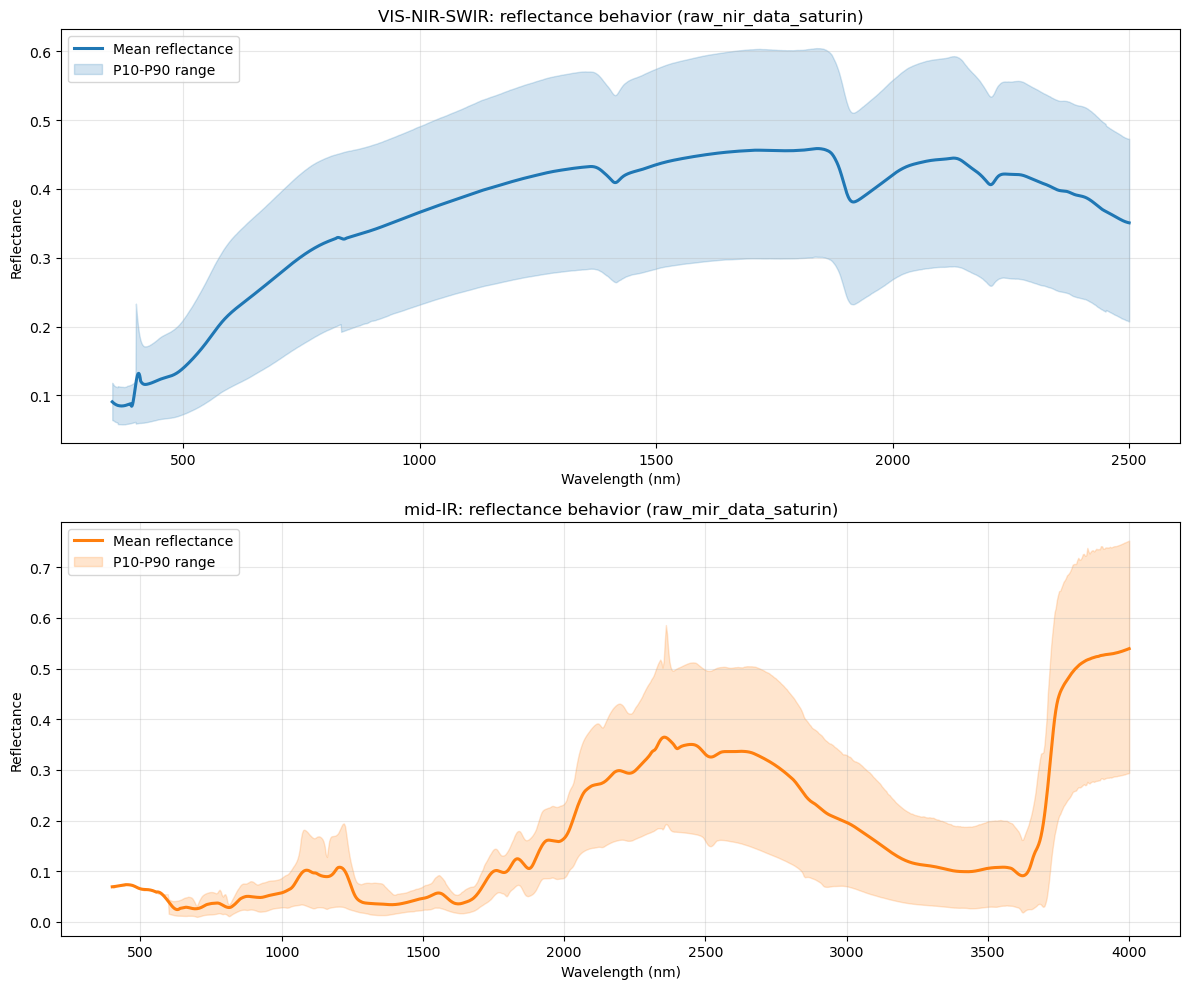

NIR file: raw_nir_data_saturin.csv (encoding=latin-1)
MIR file: raw_mir_data_saturin.csv (encoding=utf-8)
NIR samples x bands: (40137, 2151)
MIR samples x bands: (49945, 901)
Saved: espectros_visnirswir.csv, espectros_midIR.csv
Saved: comportamentos_espectrais_solos.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.signal import savgol_filter

# Load real Saturin files (case variants included for portability).
nir_candidates = [
    "raw_nir_data_saturin.csv",
    "raw_nir_data_Saturin.csv",
]
mir_candidates = [
    "raw_mir_data_saturin.csv",
    "raw_mir_data_Saturin.csv",
]

def find_first_existing(candidates):
    p = next((Path(x) for x in candidates if Path(x).exists()), None)
    if p is None:
        raise FileNotFoundError(f"File not found. Tried: {candidates}")
    return p

def read_csv_flexible(path):
    encodings = ["utf-8", "utf-8-sig", "latin-1", "cp1252"]
    last_err = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False), enc
        except UnicodeDecodeError as err:
            last_err = err
    raise UnicodeDecodeError(last_err.encoding, last_err.object, last_err.start, last_err.end, "Unable to decode CSV")

def spectral_columns(df):
    wl = sorted(int(c) for c in df.columns if str(c).isdigit())
    cols = [str(w) for w in wl]
    return cols, wl

nir_file = find_first_existing(nir_candidates)
mir_file = find_first_existing(mir_candidates)

df_nir, enc_nir = read_csv_flexible(nir_file)
df_mir, enc_mir = read_csv_flexible(mir_file)

nir_cols, nir_wl = spectral_columns(df_nir)
mir_cols, mir_wl = spectral_columns(df_mir)

if not nir_cols or not mir_cols:
    raise ValueError("Could not detect numeric spectral columns in NIR/MIR files.")

nir_spec = df_nir[nir_cols].apply(pd.to_numeric, errors="coerce")
mir_spec = df_mir[mir_cols].apply(pd.to_numeric, errors="coerce")

nir_spec = nir_spec.fillna(nir_spec.median())
mir_spec = mir_spec.fillna(mir_spec.median())

wl_visnirswir = np.array(nir_wl)
wl_midir = np.array(mir_wl)

nir_mean = nir_spec.mean(axis=0).to_numpy()
mir_mean = mir_spec.mean(axis=0).to_numpy()
nir_p10 = nir_spec.quantile(0.10, axis=0).to_numpy()
nir_p90 = nir_spec.quantile(0.90, axis=0).to_numpy()
mir_p10 = mir_spec.quantile(0.10, axis=0).to_numpy()
mir_p90 = mir_spec.quantile(0.90, axis=0).to_numpy()

def smooth_curve(y):
    n = len(y)
    win = min(21, n if n % 2 == 1 else n - 1)
    if win < 5:
        return y
    return savgol_filter(y, window_length=win, polyorder=3)

nir_mean_s = smooth_curve(nir_mean)
mir_mean_s = smooth_curve(mir_mean)

# Save compact outputs for downstream usage.
pd.DataFrame({"wl_nm": wl_visnirswir, "reflectance_mean": nir_mean_s}).to_csv("espectros_visnirswir.csv", index=False)
pd.DataFrame({"wl_nm": wl_midir, "reflectance_mean": mir_mean_s}).to_csv("espectros_midIR.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# VIS-NIR-SWIR
axes[0].plot(wl_visnirswir, nir_mean_s, color="tab:blue", linewidth=2.2, label="Mean reflectance")
axes[0].fill_between(wl_visnirswir, nir_p10, nir_p90, color="tab:blue", alpha=0.2, label="P10-P90 range")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Reflectance")
axes[0].set_title("VIS-NIR-SWIR: reflectance behavior (raw_nir_data_saturin)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# mid-IR
axes[1].plot(wl_midir, mir_mean_s, color="tab:orange", linewidth=2.2, label="Mean reflectance")
axes[1].fill_between(wl_midir, mir_p10, mir_p90, color="tab:orange", alpha=0.2, label="P10-P90 range")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Reflectance")
axes[1].set_title("mid-IR: reflectance behavior (raw_mir_data_saturin)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comportamentos_espectrais_solos.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"NIR file: {nir_file.name} (encoding={enc_nir})")
print(f"MIR file: {mir_file.name} (encoding={enc_mir})")
print(f"NIR samples x bands: {nir_spec.shape}")
print(f"MIR samples x bands: {mir_spec.shape}")
print("Saved: espectros_visnirswir.csv, espectros_midIR.csv")
print("Saved: comportamentos_espectrais_solos.png")

NIR: raw_nir_data_saturin.csv | shape=(40137, 2151)
MIR: raw_mir_data_saturin.csv | shape=(49945, 901)

=== AMOSTRA 0 ===


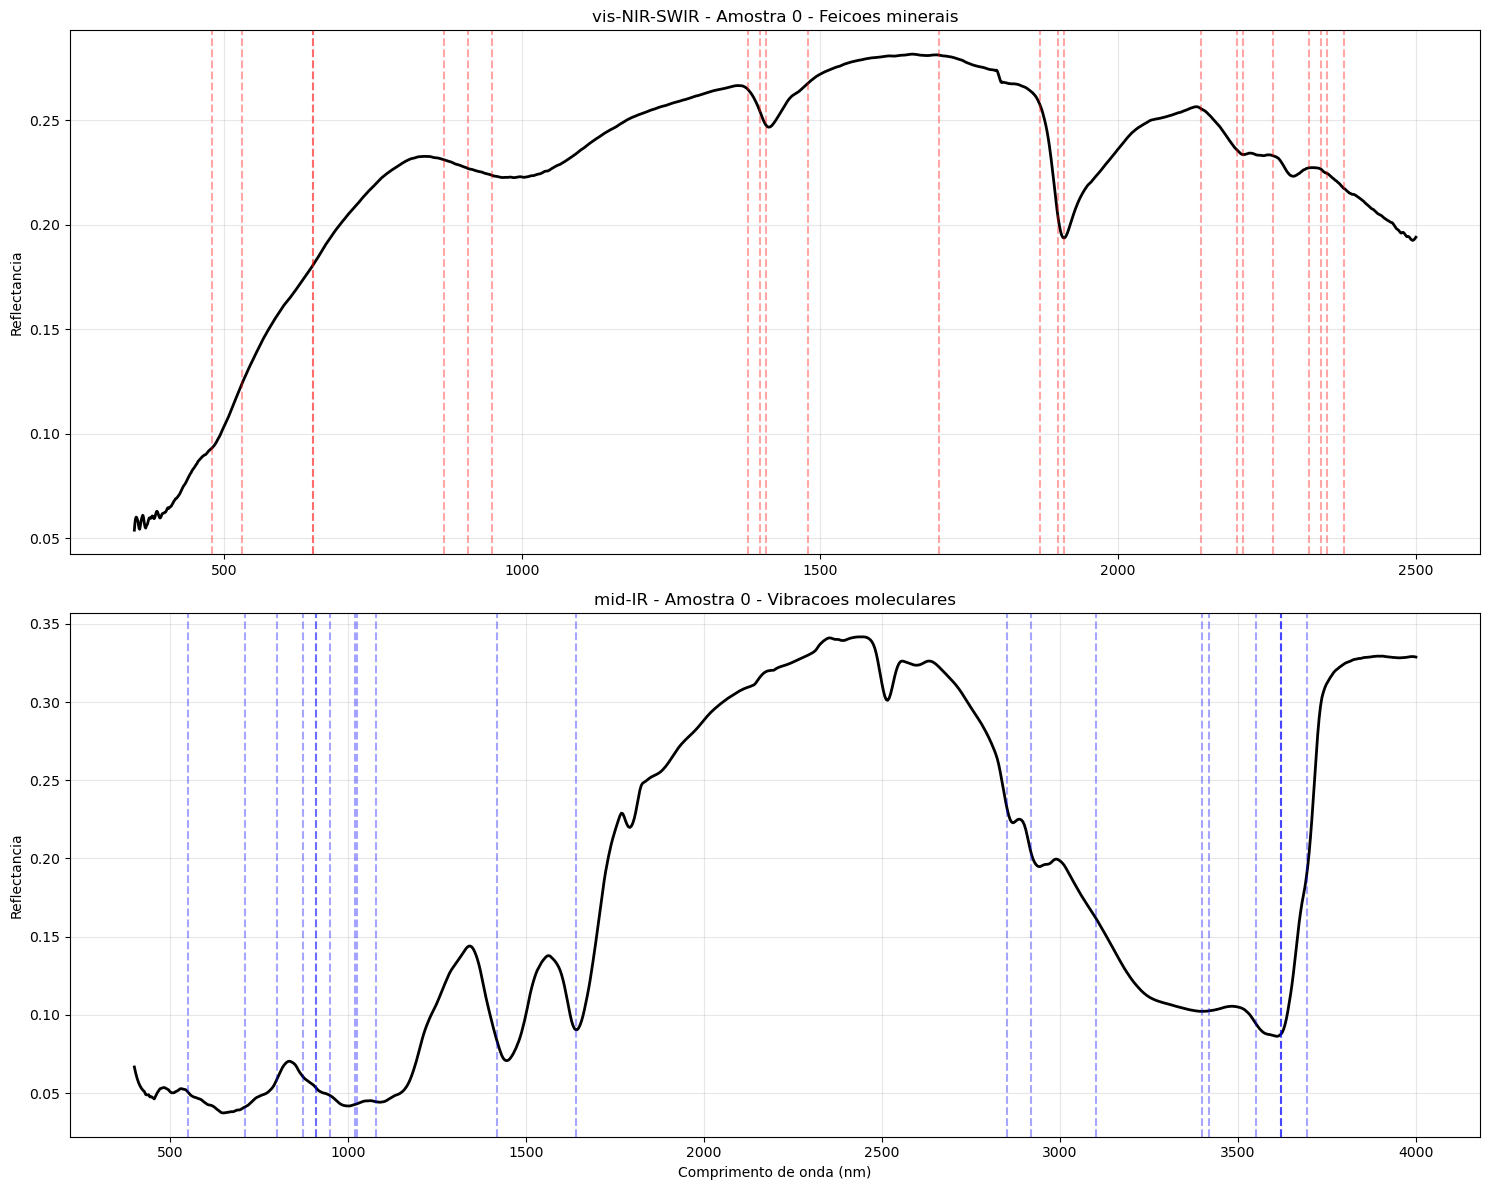


MINERAIS IDENTIFICADOS - Amostra 0:
quartzo: NIR=[], MIR=[1080, 950, 800], Conf=0.60
hematita: NIR=[530, 650], MIR=[550, 910], Conf=0.80
goethita: NIR=[480, 650, 950], MIR=[910], Conf=0.67
gibbsita: NIR=[], MIR=[3420, 3620, 1020], Conf=0.60
caulinita_1_1: NIR=[], MIR=[3620, 1025], Conf=0.33
filossilicato_2_1: NIR=[1910], MIR=[3620, 3550], Conf=0.60
carbonato: NIR=[], MIR=[1420, 875, 712], Conf=0.75
materia_organica: NIR=[2380], MIR=[], Conf=0.20
agua: NIR=[1900], MIR=[3400, 1640], Conf=0.75

=== AMOSTRA 1 ===


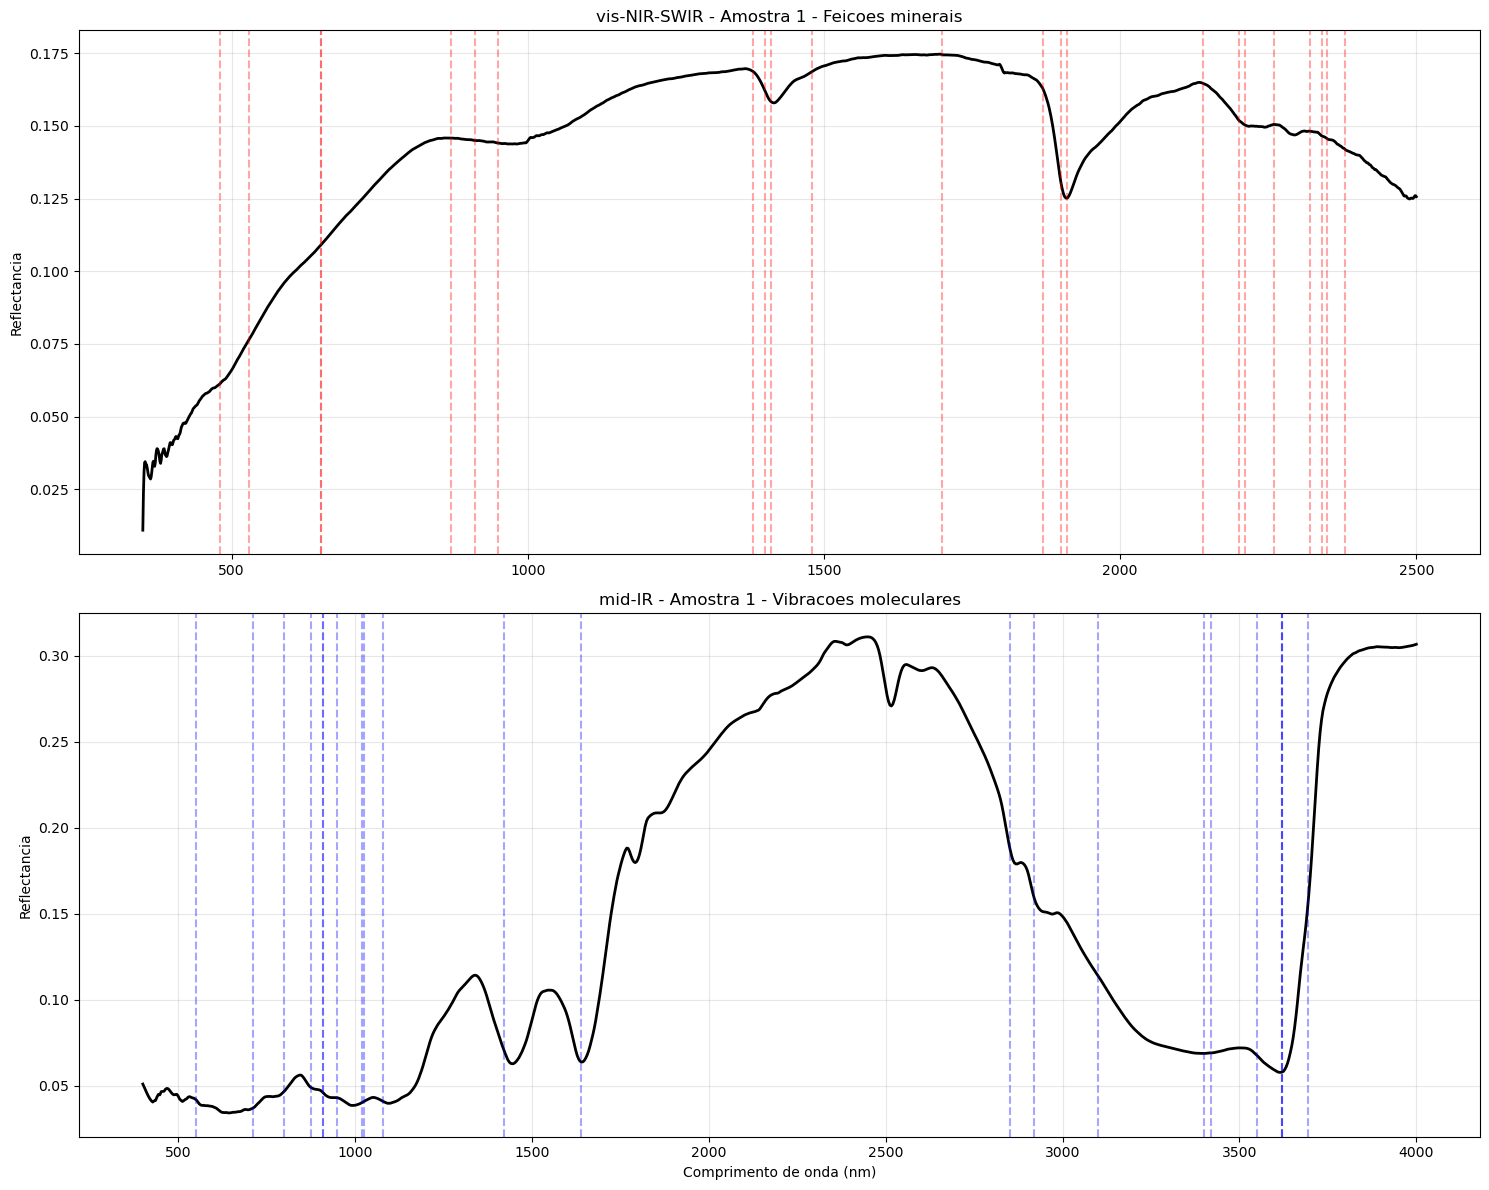


MINERAIS IDENTIFICADOS - Amostra 1:
quartzo: NIR=[], MIR=[1080, 950, 800], Conf=0.60
hematita: NIR=[530, 650], MIR=[550, 910], Conf=0.80
goethita: NIR=[480, 650, 950], MIR=[910], Conf=0.67
gibbsita: NIR=[], MIR=[3420, 3620, 1020], Conf=0.60
caulinita_1_1: NIR=[], MIR=[3620, 1025], Conf=0.33
filossilicato_2_1: NIR=[1910], MIR=[3620, 3550], Conf=0.60
carbonato: NIR=[], MIR=[1420, 875, 712], Conf=0.75
materia_organica: NIR=[2380], MIR=[], Conf=0.20
agua: NIR=[1900], MIR=[3400, 1640], Conf=0.75

=== AMOSTRA 2 ===


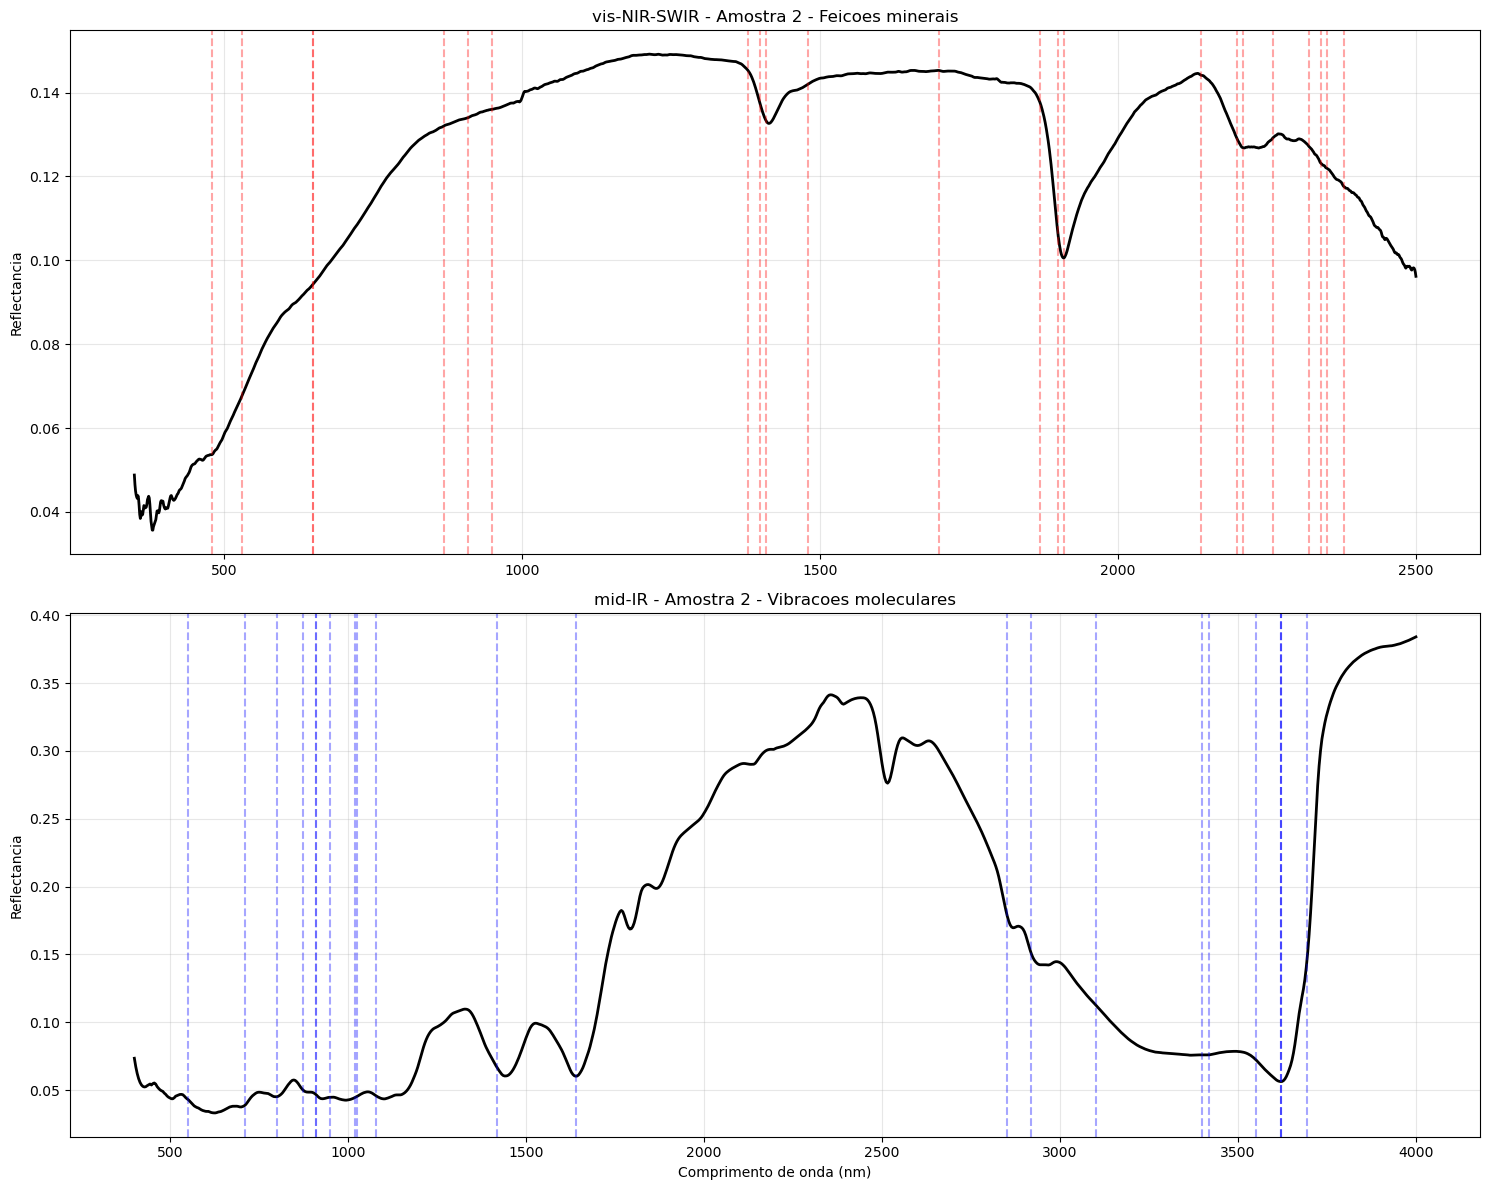


MINERAIS IDENTIFICADOS - Amostra 2:
quartzo: NIR=[], MIR=[1080, 950, 800], Conf=0.60
hematita: NIR=[530, 650], MIR=[550, 910], Conf=0.80
goethita: NIR=[480, 650], MIR=[910], Conf=0.50
gibbsita: NIR=[], MIR=[3420, 3620, 1020], Conf=0.60
caulinita_1_1: NIR=[], MIR=[3620, 1025], Conf=0.33
filossilicato_2_1: NIR=[1910, 2350], MIR=[3620, 3550], Conf=0.80
carbonato: NIR=[2340], MIR=[1420, 875, 712], Conf=1.00
materia_organica: NIR=[2380], MIR=[], Conf=0.20
agua: NIR=[1900], MIR=[3400, 1640], Conf=0.75


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import gaussian_filter1d
import warnings
warnings.filterwarnings('ignore')

class DetectorMineraisSolo:
    def __init__(self, nir_file='raw_nir_data_saturin.csv', mir_file='raw_mir_data_saturin.csv'):
        self.nir_file = self._resolve_file([nir_file, 'raw_nir_data_Saturin.csv'])
        self.mir_file = self._resolve_file([mir_file, 'raw_mir_data_Saturin.csv'])
        self.nir_data = self._read_csv_flexible(self.nir_file)
        self.mir_data = self._read_csv_flexible(self.mir_file)
        self.mineral_features = self._definir_feicoes_minerais()

    def _resolve_file(self, candidates):
        p = next((Path(c) for c in candidates if Path(c).exists()), None)
        if p is None:
            raise FileNotFoundError(f'Arquivo nao encontrado. Tentativas: {candidates}')
        return p

    def _read_csv_flexible(self, path):
        for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
            try:
                return pd.read_csv(path, encoding=enc, low_memory=False)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError('utf-8', b'', 0, 1, f'Falha ao ler {path.name}')

    def _definir_feicoes_minerais(self):
        """Dicionario com feicoes espectrais por mineral (nm)."""
        return {
            'quartzo': {'nir': [1380, 1870], 'mir': [1080, 950, 800]},
            'hematita': {'nir': [530, 650, 870], 'mir': [550, 910]},
            'goethita': {'nir': [480, 650, 910, 950], 'mir': [3100, 910]},
            'gibbsita': {'nir': [2260, 1480], 'mir': [3420, 3620, 1020]},
            'caulinita_1_1': {'nir': [1410, 2210, 2320], 'mir': [3695, 3620, 1025]},
            'filossilicato_2_1': {'nir': [1910, 2200, 2350], 'mir': [3620, 3550]},
            'carbonato': {'nir': [2340], 'mir': [1420, 875, 712]},
            'materia_organica': {'nir': [1700, 2140, 2380], 'mir': [2920, 2850]},
            'agua': {'nir': [1400, 1900], 'mir': [3400, 1640]}
        }

    def _spectral_columns(self, df):
        wl = sorted(int(c) for c in df.columns if str(c).isdigit())
        cols = [str(w) for w in wl]
        return cols, np.array(wl)

    def _sg_smooth(self, arr, max_win=15):
        n = arr.shape[1]
        win = min(max_win, n if n % 2 == 1 else n - 1)
        if win < 5:
            return arr
        return savgol_filter(arr, win, 3, axis=1)

    def processar_espectros(self):
        """Extrai matriz espectral real dos arquivos Saturin e aplica pre-processamento."""
        nir_cols, self.nir_wl = self._spectral_columns(self.nir_data)
        mir_cols, self.mir_wl = self._spectral_columns(self.mir_data)

        if not nir_cols or not mir_cols:
            raise ValueError('Nao foi possivel identificar colunas espectrais numericas em NIR/MIR.')

        nir_df = self.nir_data[nir_cols].apply(pd.to_numeric, errors='coerce')
        mir_df = self.mir_data[mir_cols].apply(pd.to_numeric, errors='coerce')

        self.nir_spectra = nir_df.fillna(nir_df.median()).to_numpy()
        self.mir_spectra = mir_df.fillna(mir_df.median()).to_numpy()

        self.nir_spectra_sg = self._sg_smooth(self.nir_spectra, max_win=11)
        self.mir_spectra_sg = self._sg_smooth(self.mir_spectra, max_win=15)

    def detectar_feicoes(self, espectro, wl, prominence=0.02):
        """Detecta vales de absorcao no espectro."""
        espectro_smooth = gaussian_filter1d(espectro, sigma=1)
        peaks, _ = find_peaks(-espectro_smooth, prominence=prominence)
        return wl[peaks]

    def identificar_minerais(self, idx_amostra=0):
        """Identifica minerais na amostra especifica usando proximidade espectral."""
        nir_spec = self.nir_spectra_sg[idx_amostra]
        mir_spec = self.mir_spectra_sg[idx_amostra]

        nir_threshold = np.quantile(nir_spec, 0.35)
        mir_threshold = np.quantile(mir_spec, 0.35)

        resultados = {}
        for mineral, feicoes in self.mineral_features.items():
            matches_nir = []
            matches_mir = []

            for feat in feicoes.get('nir', []):
                idx = int(np.argmin(np.abs(self.nir_wl - feat)))
                if nir_spec[idx] <= nir_threshold:
                    matches_nir.append(feat)

            for feat in feicoes.get('mir', []):
                idx = int(np.argmin(np.abs(self.mir_wl - feat)))
                if mir_spec[idx] <= mir_threshold:
                    matches_mir.append(feat)

            total_feats = len(feicoes.get('nir', [])) + len(feicoes.get('mir', []))
            if matches_nir or matches_mir:
                resultados[mineral] = {
                    'nir_matches': matches_nir,
                    'mir_matches': matches_mir,
                    'confianca': (len(matches_nir) + len(matches_mir)) / max(total_feats, 1)
                }

        return resultados

    def plot_identificacao(self, idx_amostra=0):
        """Grafico com feicoes espectrais mineraloquimicas da amostra."""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

        ax1.plot(self.nir_wl, self.nir_spectra_sg[idx_amostra], 'k-', linewidth=2)
        for mineral, feicoes in self.mineral_features.items():
            for feat in feicoes.get('nir', []):
                ax1.axvline(feat, color='red', alpha=0.35, linestyle='--')
        ax1.set_title(f'vis-NIR-SWIR - Amostra {idx_amostra} - Feicoes minerais')
        ax1.set_ylabel('Reflectancia')
        ax1.grid(alpha=0.3)

        ax2.plot(self.mir_wl, self.mir_spectra_sg[idx_amostra], 'k-', linewidth=2)
        for mineral, feicoes in self.mineral_features.items():
            for feat in feicoes.get('mir', []):
                ax2.axvline(feat, color='blue', alpha=0.35, linestyle='--')
        ax2.set_title(f'mid-IR - Amostra {idx_amostra} - Vibracoes moleculares')
        ax2.set_xlabel('Comprimento de onda (nm)')
        ax2.set_ylabel('Reflectancia')
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'identificacao_minerais_amostra_{idx_amostra}.png', dpi=300)
        plt.show()

        resultados = self.identificar_minerais(idx_amostra)
        print(f"\nMINERAIS IDENTIFICADOS - Amostra {idx_amostra}:")
        for mineral, info in resultados.items():
            print(
                f"{mineral}: NIR={info['nir_matches']}, MIR={info['mir_matches']}, "
                f"Conf={info['confianca']:.2f}"
            )

# Usar com seus arquivos reais Saturin
detector = DetectorMineraisSolo('raw_nir_data_saturin.csv', 'raw_mir_data_saturin.csv')
detector.processar_espectros()

print(f'NIR: {detector.nir_file.name} | shape={detector.nir_spectra.shape}')
print(f'MIR: {detector.mir_file.name} | shape={detector.mir_spectra.shape}')

# Analisar primeiras 3 amostras
for i in range(min(3, len(detector.nir_spectra_sg))):
    print(f"\n=== AMOSTRA {i} ===")
    detector.plot_identificacao(i)
    detector.identificar_minerais(i)

GEOCIS - Detector Minerais Saturin NIR/MIR
NIR loaded: (40137, 2173) | MIR loaded: (49945, 923)
NIR bands: 2151 (350-2500 nm)
MIR bands: 901 (400-4000 nm)



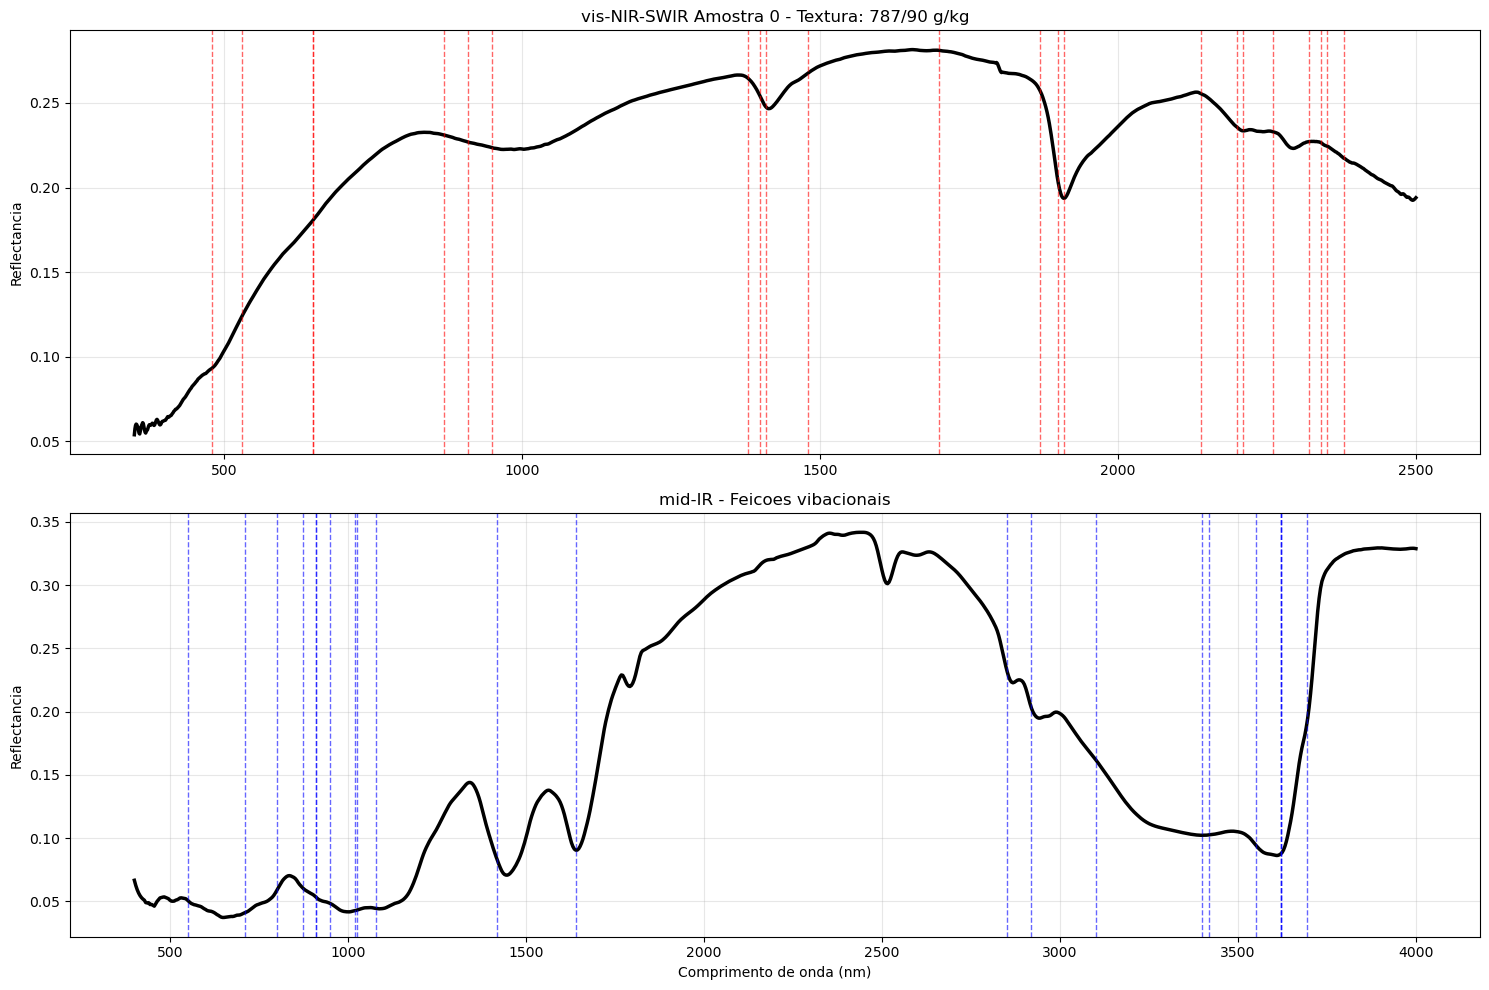


MINERAIS - Amostra 0:
  hematita           0.80
  carbonato          0.75
  agua               0.75
  goethita           0.67
  quartzo            0.60



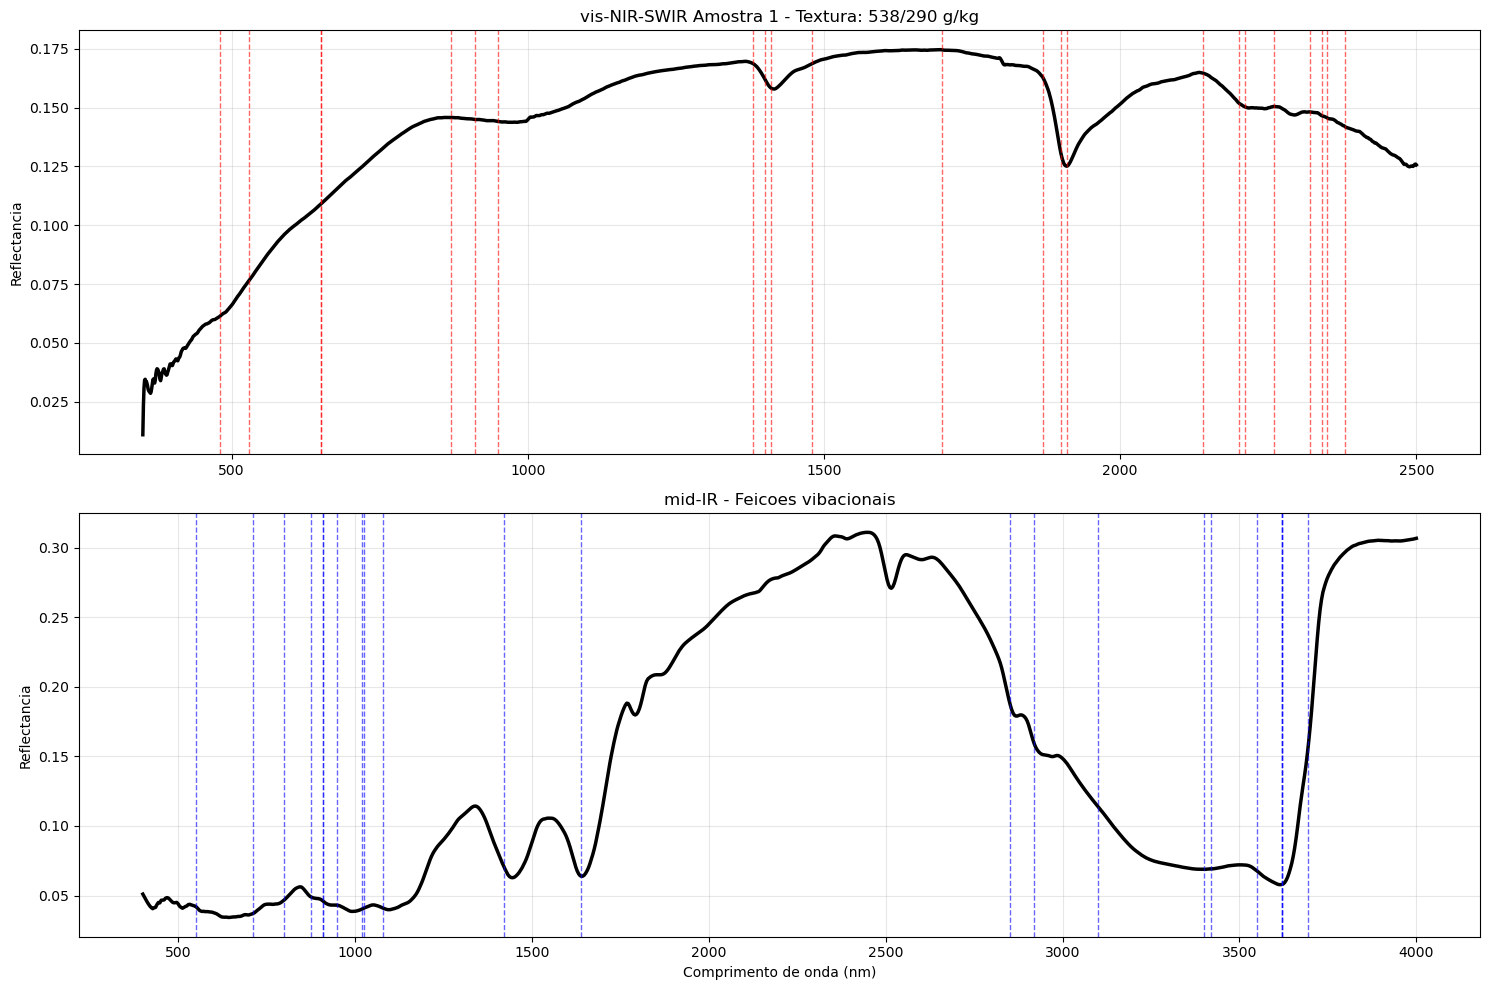


MINERAIS - Amostra 1:
  hematita           0.80
  carbonato          0.75
  agua               0.75
  goethita           0.67
  quartzo            0.60



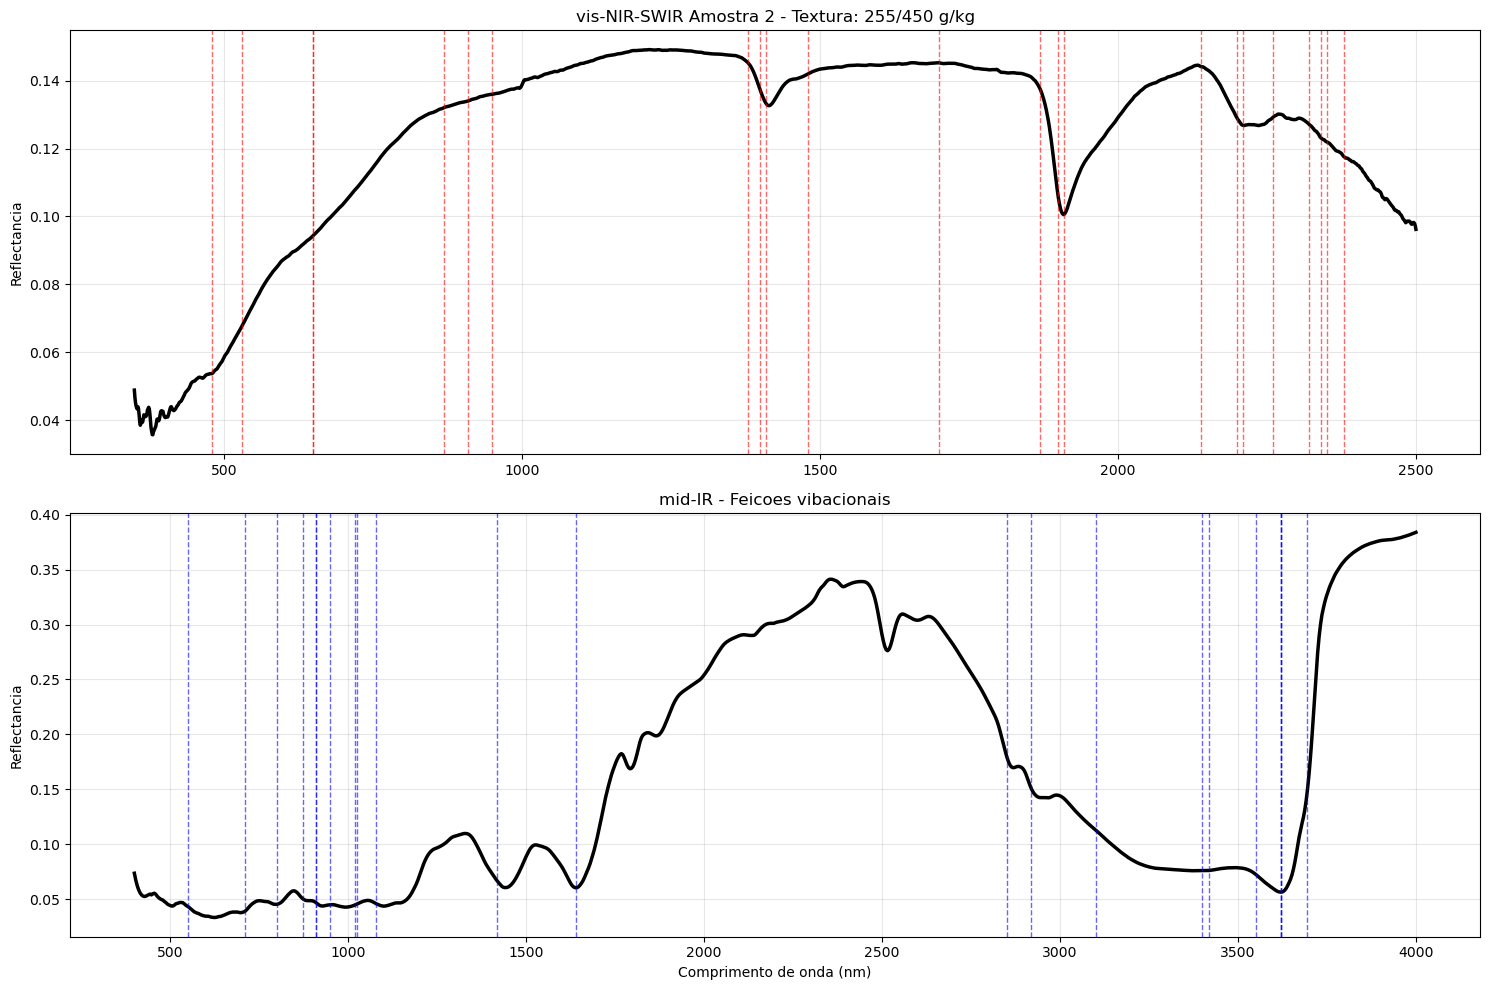


MINERAIS - Amostra 2:
  carbonato          1.00
  hematita           0.80
  montmorilonita_2_1 0.80
  agua               0.75
  quartzo            0.60

GEOCIS Mineral Detector concluido.
Arquivos PNG salvos para cada amostra.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

class DetectorMineraisSaturin:
    def __init__(self, nir_file='raw_nir_data_saturin.csv', mir_file='raw_mir_data_saturin.csv'):
        print('GEOCIS - Detector Minerais Saturin NIR/MIR')
        self.nir_file = self._resolve_file([nir_file, 'raw_nir_data_Saturin.csv'])
        self.mir_file = self._resolve_file([mir_file, 'raw_mir_data_Saturin.csv'])
        self.nir_data = self._read_csv_flexible(self.nir_file)
        self.mir_data = self._read_csv_flexible(self.mir_file)
        self.mineral_features = self._definir_feicoes()
        print(f'NIR loaded: {self.nir_data.shape} | MIR loaded: {self.mir_data.shape}')

    def _resolve_file(self, candidates):
        p = next((Path(c) for c in candidates if Path(c).exists()), None)
        if p is None:
            raise FileNotFoundError(f'Arquivo nao encontrado. Tentativas: {candidates}')
        return p

    def _read_csv_flexible(self, path):
        for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
            try:
                return pd.read_csv(path, encoding=enc, low_memory=False)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError('utf-8', b'', 0, 1, f'Falha ao ler {path.name}')

    def _definir_feicoes(self):
        """Feicoes validadas para solos tropicais (Dematte, Wadoux)."""
        return {
            'quartzo': {'nir': [1380, 1870], 'mir': [1080, 950, 800]},
            'hematita': {'nir': [530, 650, 870], 'mir': [550, 910]},
            'goethita': {'nir': [480, 650, 910, 950], 'mir': [3100, 910]},
            'gibbsita': {'nir': [1480, 2260], 'mir': [3420, 3620, 1020]},
            'caulinita': {'nir': [1410, 2210, 2320], 'mir': [3695, 3620, 1025]},
            'montmorilonita_2_1': {'nir': [1910, 2200, 2350], 'mir': [3620, 3550]},
            'carbonato': {'nir': [2340], 'mir': [1420, 875, 712]},
            'materia_organica': {'nir': [1700, 2140, 2380], 'mir': [2920, 2850]},
            'agua': {'nir': [1400, 1900], 'mir': [3400, 1640]}
        }

    def _spectral_columns(self, df):
        wl = sorted(int(c) for c in df.columns if str(c).isdigit())
        cols = [str(w) for w in wl]
        return cols, np.array(wl)

    def _sg_2d(self, arr, max_win=15):
        n = arr.shape[1]
        win = min(max_win, n if n % 2 == 1 else n - 1)
        if win < 5:
            return arr
        return savgol_filter(arr, win, 3, axis=1)

    def _extrair_espectros_nir(self):
        nir_cols, self.nir_wl = self._spectral_columns(self.nir_data)
        if not nir_cols:
            raise ValueError('Nenhuma coluna espectral NIR numerica encontrada.')
        nir_df = self.nir_data[nir_cols].apply(pd.to_numeric, errors='coerce')
        self.nir_spectra = nir_df.fillna(nir_df.median()).to_numpy()
        self.nir_spectra_sg = self._sg_2d(self.nir_spectra, max_win=11)
        print(f'NIR bands: {len(nir_cols)} ({self.nir_wl.min()}-{self.nir_wl.max()} nm)')

    def _extrair_espectros_mir(self):
        mir_cols, self.mir_wl = self._spectral_columns(self.mir_data)
        if not mir_cols:
            raise ValueError('Nenhuma coluna espectral MIR numerica encontrada.')
        mir_df = self.mir_data[mir_cols].apply(pd.to_numeric, errors='coerce')
        self.mir_spectra = mir_df.fillna(mir_df.median()).to_numpy()
        self.mir_spectra_sg = self._sg_2d(self.mir_spectra, max_win=15)
        print(f'MIR bands: {len(mir_cols)} ({self.mir_wl.min()}-{self.mir_wl.max()} nm)')

    def processar(self):
        self._extrair_espectros_nir()
        self._extrair_espectros_mir()

    def analisar_amostra(self, idx=0):
        nir_spec = self.nir_spectra_sg[idx]
        mir_spec = self.mir_spectra_sg[idx]

        nir_threshold = np.quantile(nir_spec, 0.35)
        mir_threshold = np.quantile(mir_spec, 0.35)

        resultados = {}
        for mineral, feicoes in self.mineral_features.items():
            score_nir = 0
            score_mir = 0

            for feat in feicoes.get('nir', []):
                idx_feat = int(np.argmin(np.abs(self.nir_wl - feat)))
                if nir_spec[idx_feat] <= nir_threshold:
                    score_nir += 1

            for feat in feicoes.get('mir', []):
                idx_feat = int(np.argmin(np.abs(self.mir_wl - feat)))
                if mir_spec[idx_feat] <= mir_threshold:
                    score_mir += 1

            total_feats = len(feicoes.get('nir', [])) + len(feicoes.get('mir', []))
            score_total = score_nir + score_mir
            if score_total > 0 and total_feats > 0:
                resultados[mineral] = score_total / total_feats

        return sorted(resultados.items(), key=lambda x: x[1], reverse=True)

    def _pick_texture_col(self, df, candidates):
        return next((c for c in candidates if c in df.columns), None)

    def plot_minerais(self, idx=0):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

        ax1.plot(self.nir_wl, self.nir_spectra_sg[idx], 'k-', linewidth=2.5)
        for mineral, feicoes in self.mineral_features.items():
            for feat in feicoes.get('nir', []):
                ax1.axvline(feat, color='red', alpha=0.6, linestyle='--', lw=1)

        sand_col = self._pick_texture_col(self.nir_data, ['sand_gkg', 'Sand_gkg'])
        clay_col = self._pick_texture_col(self.nir_data, ['clay_gkg', 'Clay_gkg'])
        if sand_col and clay_col:
            sand_val = float(self.nir_data.iloc[idx][sand_col])
            clay_val = float(self.nir_data.iloc[idx][clay_col])
            title = f'vis-NIR-SWIR Amostra {idx} - Textura: {sand_val:.0f}/{clay_val:.0f} g/kg'
        else:
            title = f'vis-NIR-SWIR Amostra {idx}'

        ax1.set_title(title)
        ax1.set_ylabel('Reflectancia')
        ax1.grid(True, alpha=0.3)

        ax2.plot(self.mir_wl, self.mir_spectra_sg[idx], 'k-', linewidth=2.5)
        for mineral, feicoes in self.mineral_features.items():
            for feat in feicoes.get('mir', []):
                ax2.axvline(feat, color='blue', alpha=0.6, linestyle='--', lw=1)

        ax2.set_title('mid-IR - Feicoes vibacionais')
        ax2.set_xlabel('Comprimento de onda (nm)')
        ax2.set_ylabel('Reflectancia')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'minerais_saturin_amostra_{idx}.png', dpi=300, bbox_inches='tight')
        plt.show()

        minerais = self.analisar_amostra(idx)
        print(f'\nMINERAIS - Amostra {idx}:')
        for mineral, score in minerais[:5]:
            print(f'  {mineral:<18} {score:.2f}')

# EXECUTAR
detector3 = DetectorMineraisSaturin('raw_nir_data_saturin.csv', 'raw_mir_data_saturin.csv')
detector3.processar()

# Analisar primeiras 3 amostras
for i in range(min(3, len(detector3.nir_data))):
    print('\n' + '=' * 50)
    detector3.plot_minerais(i)

print('\nGEOCIS Mineral Detector concluido.')
print('Arquivos PNG salvos para cada amostra.')

GEOCIS - Detector Feicoes Espectrais Exatas
NIR loaded: (40137, 2151), wavelengths 350-2500 nm
MIR loaded: (49945, 901), wavelengths 400-4000 nm



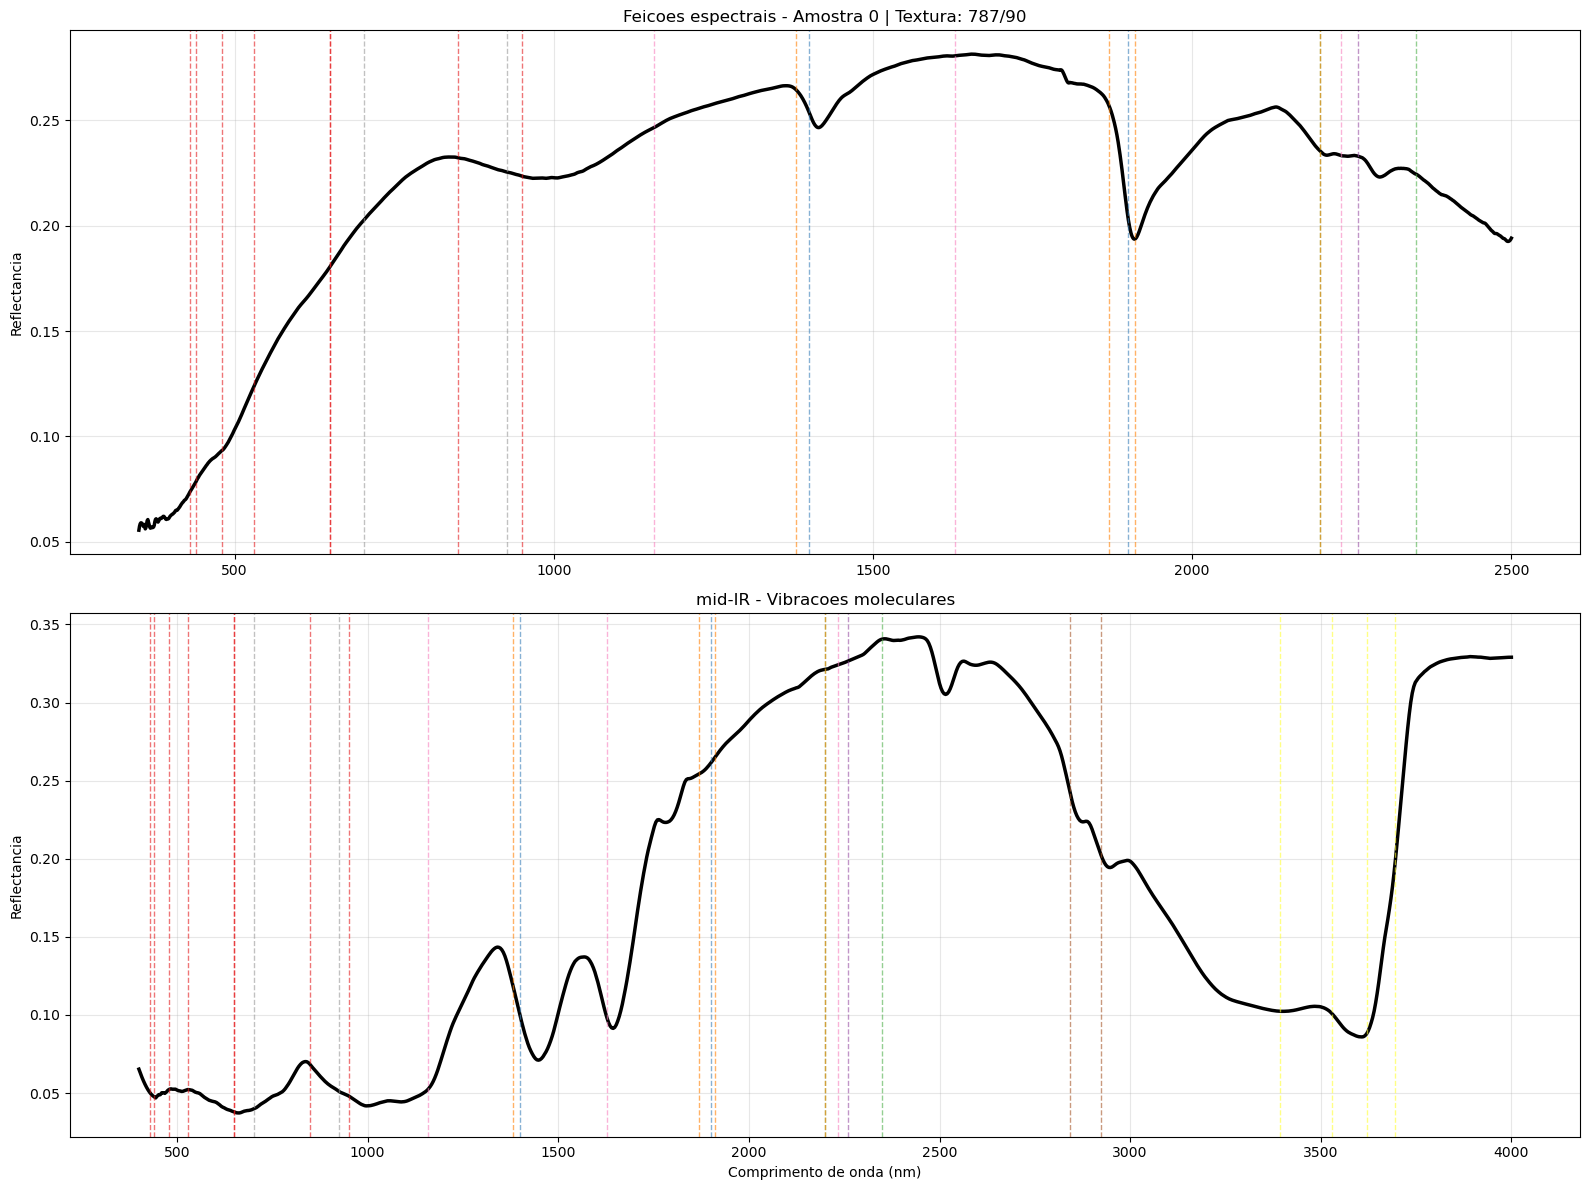


FEICOES DETECTADAS - Amostra 0:
  Fe3+_goethita          1.00
  hematita_ofe           1.00
  Fe3+_hematita          0.75
  filossilicatos_aloh    0.75
  agua_filossilicatos    0.50
  filossilicatos_2_1_osi 0.50



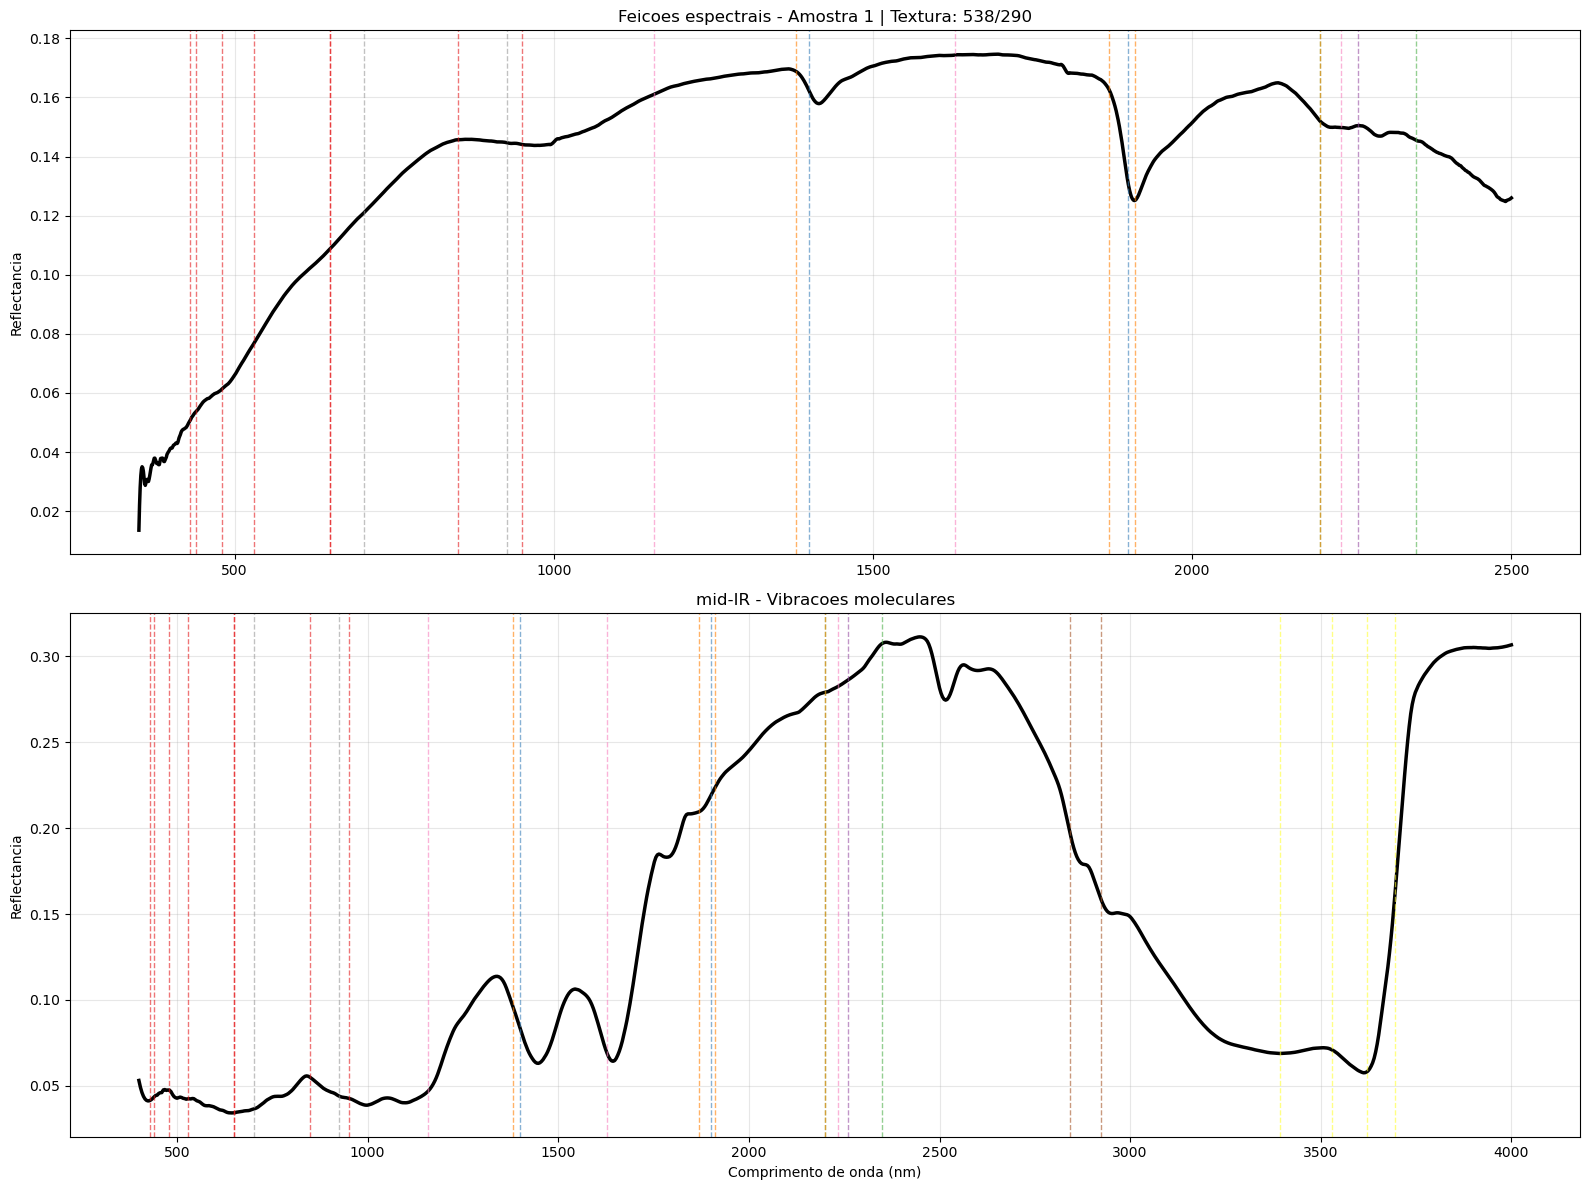


FEICOES DETECTADAS - Amostra 1:
  Fe3+_goethita          1.00
  hematita_ofe           1.00
  Fe3+_hematita          0.75
  filossilicatos_aloh    0.75
  agua_filossilicatos    0.50
  filossilicatos_2_1_osi 0.50



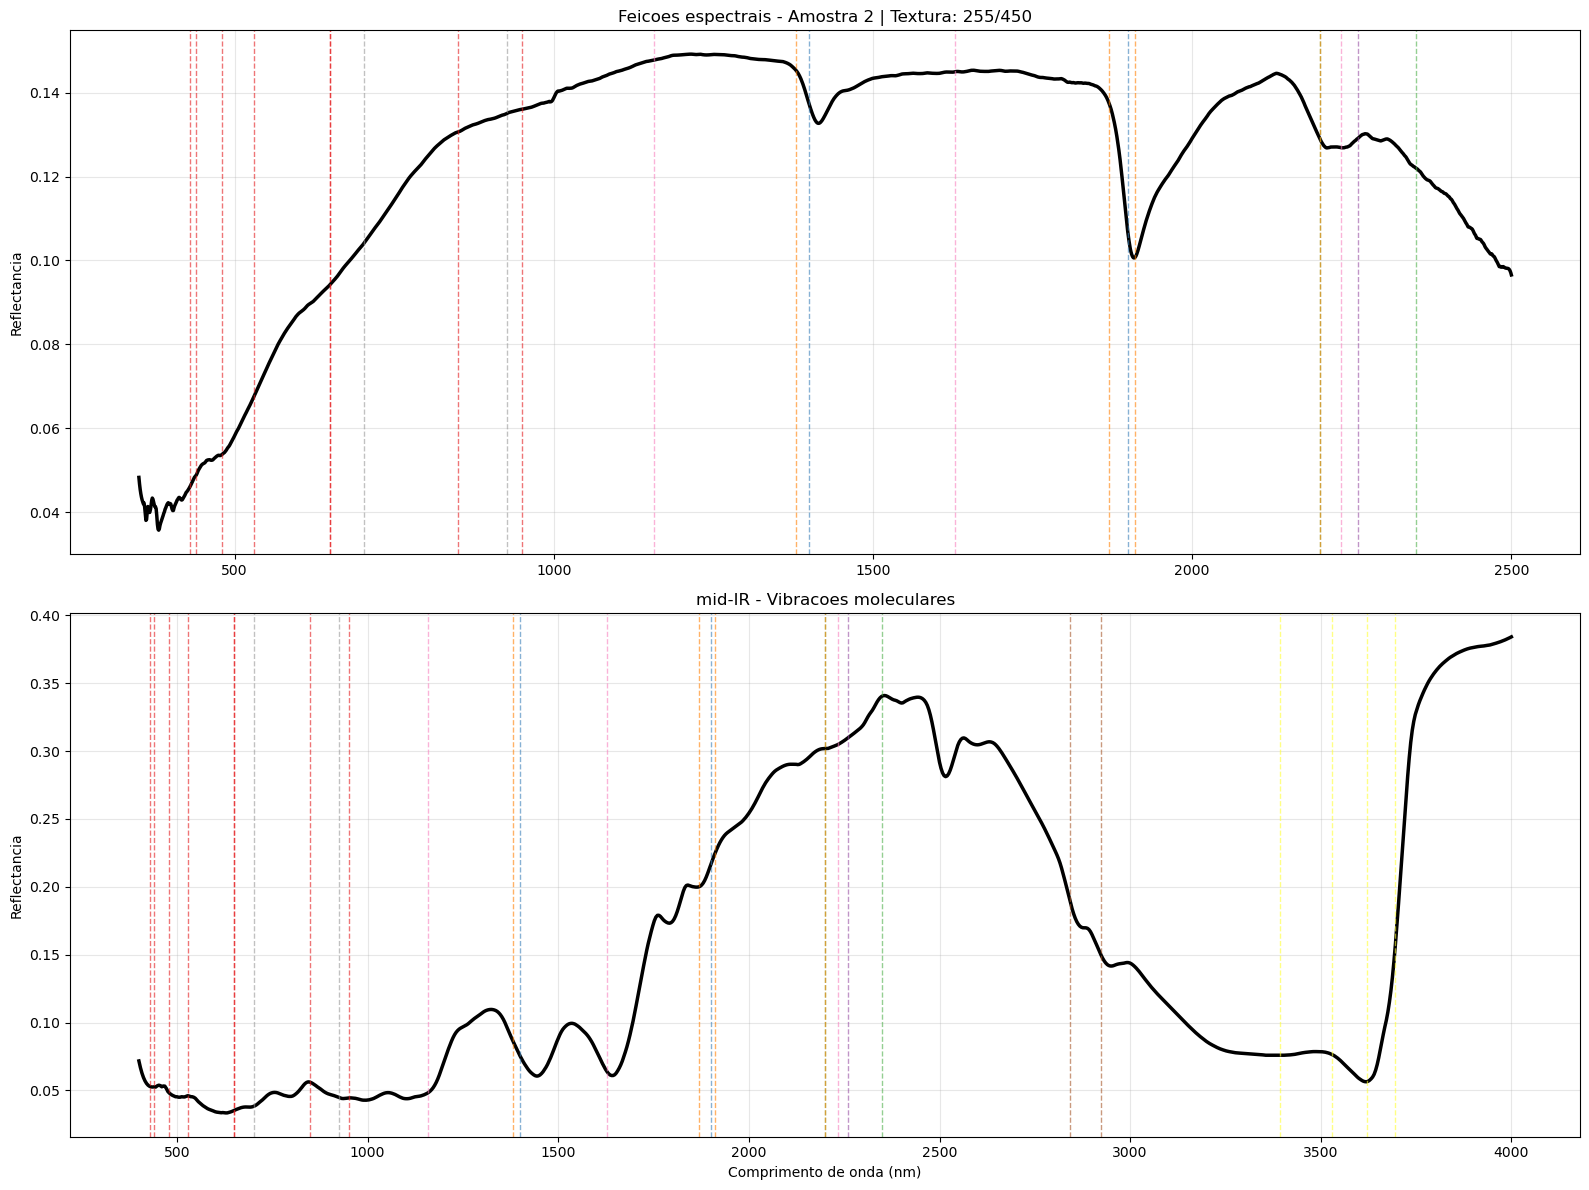


FEICOES DETECTADAS - Amostra 2:
  hematita_ofe           1.00
  Fe3+_goethita          0.75
  Fe3+_hematita          0.75
  filossilicatos_aloh    0.75
  agua_filossilicatos    0.50
  filossilicatos_ohal    0.50
  filossilicatos_2_1_osi 0.50


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

class DetectorFeicoesSaturin:
    def __init__(self, nir_file='raw_nir_data_saturin.csv', mir_file='raw_mir_data_saturin.csv'):
        print('GEOCIS - Detector Feicoes Espectrais Exatas')
        self.nir_file = self._resolve_file([nir_file, 'raw_nir_data_Saturin.csv'])
        self.mir_file = self._resolve_file([mir_file, 'raw_mir_data_Saturin.csv'])
        self.nir_data = self._read_csv_flexible(self.nir_file)
        self.mir_data = self._read_csv_flexible(self.mir_file)
        self.feicoes = self._carregar_feicoes_exatas()

    def _resolve_file(self, candidates):
        p = next((Path(c) for c in candidates if Path(c).exists()), None)
        if p is None:
            raise FileNotFoundError(f'Arquivo nao encontrado. Tentativas: {candidates}')
        return p

    def _read_csv_flexible(self, path):
        for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
            try:
                return pd.read_csv(path, encoding=enc, low_memory=False)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError('utf-8', b'', 0, 1, f'Falha ao ler {path.name}')

    def _carregar_feicoes_exatas(self):
        """Tabela de feicoes (nm) para NIR/SWIR e mid-IR."""
        return {
            'Fe3+_goethita': [430, 480, 650, 950],
            'Fe3+_hematita': [440, 530, 650, 850],
            'agua_filossilicatos': [1400, 1900],
            'filossilicatos_ohal': [2200, 2350],
            'gibbsita': [2260],
            'quartzo_osi': [1380, 1870],
            'filossilicatos_2_1_osi': [1910, 2200],
            'filossilicatos_aloh': [3394, 3529, 3622, 3695],
            'materia_organica_ch': [2843, 2924],
            'quartzo_mir': [1157, 1628, 2233],
            'goethita_ofe': [926],
            'hematita_ofe': [702],
        }

    def _spectral_columns(self, df):
        wl = sorted(int(c) for c in df.columns if str(c).isdigit())
        cols = [str(w) for w in wl]
        return cols, np.array(wl)

    def _sg_2d(self, arr, max_win=15):
        n = arr.shape[1]
        win = min(max_win, n if n % 2 == 1 else n - 1)
        if win < 5:
            return arr
        return savgol_filter(arr, win, 3, axis=1)

    def processar_dados(self):
        nir_cols, self.nir_wl = self._spectral_columns(self.nir_data)
        mir_cols, self.mir_wl = self._spectral_columns(self.mir_data)

        if not nir_cols or not mir_cols:
            raise ValueError('Nao foi possivel identificar colunas espectrais numericas em NIR/MIR.')

        nir_df = self.nir_data[nir_cols].apply(pd.to_numeric, errors='coerce')
        mir_df = self.mir_data[mir_cols].apply(pd.to_numeric, errors='coerce')

        self.nir_spectra = nir_df.fillna(nir_df.median()).to_numpy()
        self.mir_spectra = mir_df.fillna(mir_df.median()).to_numpy()

        self.nir_spectra_sg = self._sg_2d(self.nir_spectra, max_win=15)
        self.mir_spectra_sg = self._sg_2d(self.mir_spectra, max_win=21)

        print(f'NIR loaded: {self.nir_spectra.shape}, wavelengths {self.nir_wl.min()}-{self.nir_wl.max()} nm')
        print(f'MIR loaded: {self.mir_spectra.shape}, wavelengths {self.mir_wl.min()}-{self.mir_wl.max()} nm')

    def detectar_todas_feicoes(self, idx=0):
        nir_spec = self.nir_spectra_sg[idx]
        mir_spec = self.mir_spectra_sg[idx]

        nir_threshold = np.quantile(nir_spec, 0.35)
        mir_threshold = np.quantile(mir_spec, 0.35)

        resultados = {}
        for feicao, posicoes in self.feicoes.items():
            score = 0
            for pos in posicoes:
                if 350 <= pos <= 2500:
                    idx_pos = int(np.argmin(np.abs(self.nir_wl - pos)))
                    if nir_spec[idx_pos] <= nir_threshold:
                        score += 1
                elif 400 <= pos <= 4000:
                    idx_pos = int(np.argmin(np.abs(self.mir_wl - pos)))
                    if mir_spec[idx_pos] <= mir_threshold:
                        score += 1

            if score > 0:
                resultados[feicao] = score / len(posicoes)

        return dict(sorted(resultados.items(), key=lambda x: x[1], reverse=True))

    def _pick_texture_col(self, df, candidates):
        return next((c for c in candidates if c in df.columns), None)

    def plot_completo(self, idx=0):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

        ax1.plot(self.nir_wl, self.nir_spectra_sg[idx], 'k-', linewidth=2.5)
        colors = plt.cm.Set1(np.linspace(0, 1, len(self.feicoes)))
        for i, (feicao, posicoes) in enumerate(self.feicoes.items()):
            for pos in posicoes:
                if 350 <= pos <= 2500:
                    ax1.axvline(pos, color=colors[i], alpha=0.6, linestyle='--', lw=1)

        sand_col = self._pick_texture_col(self.nir_data, ['sand_gkg', 'Sand_gkg'])
        clay_col = self._pick_texture_col(self.nir_data, ['clay_gkg', 'Clay_gkg'])
        if sand_col and clay_col:
            sand_val = float(self.nir_data.iloc[idx][sand_col])
            clay_val = float(self.nir_data.iloc[idx][clay_col])
            title = f'Feicoes espectrais - Amostra {idx} | Textura: {sand_val:.0f}/{clay_val:.0f}'
        else:
            title = f'Feicoes espectrais - Amostra {idx}'

        ax1.set_title(title)
        ax1.set_ylabel('Reflectancia')
        ax1.grid(True, alpha=0.3)

        ax2.plot(self.mir_wl, self.mir_spectra_sg[idx], 'k-', linewidth=2.5)
        for i, (feicao, posicoes) in enumerate(self.feicoes.items()):
            for pos in posicoes:
                if 400 <= pos <= 4000:
                    ax2.axvline(pos, color=colors[i], alpha=0.6, linestyle='--', lw=1)

        ax2.set_title('mid-IR - Vibracoes moleculares')
        ax2.set_xlabel('Comprimento de onda (nm)')
        ax2.set_ylabel('Reflectancia')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'feicoes_exatas_saturin_{idx}.png', dpi=300, bbox_inches='tight')
        plt.show()

        feicoes_detectadas = self.detectar_todas_feicoes(idx)
        print(f'\nFEICOES DETECTADAS - Amostra {idx}:')
        for feicao, score in list(feicoes_detectadas.items())[:8]:
            print(f'  {feicao:<22} {score:.2f}')

# EXECUTAR COM SEUS DADOS
detector4 = DetectorFeicoesSaturin('raw_nir_data_saturin.csv', 'raw_mir_data_saturin.csv')
detector4.processar_dados()

# Analisar 3 primeiras amostras
for i in range(min(3, len(detector4.nir_spectra_sg), len(detector4.mir_spectra_sg))):
    print('\n' + '=' * 60)
    detector4.plot_completo(i)

## 5. Improving Soil Classification With Vis-NIR, MIR, and Spectra Fusion

This section compares three strategies on the same samples:
1. Vis-NIR only
2. MIR only
3. Spectra fusion (early fusion: Vis-NIR + MIR concatenation)

Target used here: texture class derived from Sand and Clay (sandy, loamy, clayey).

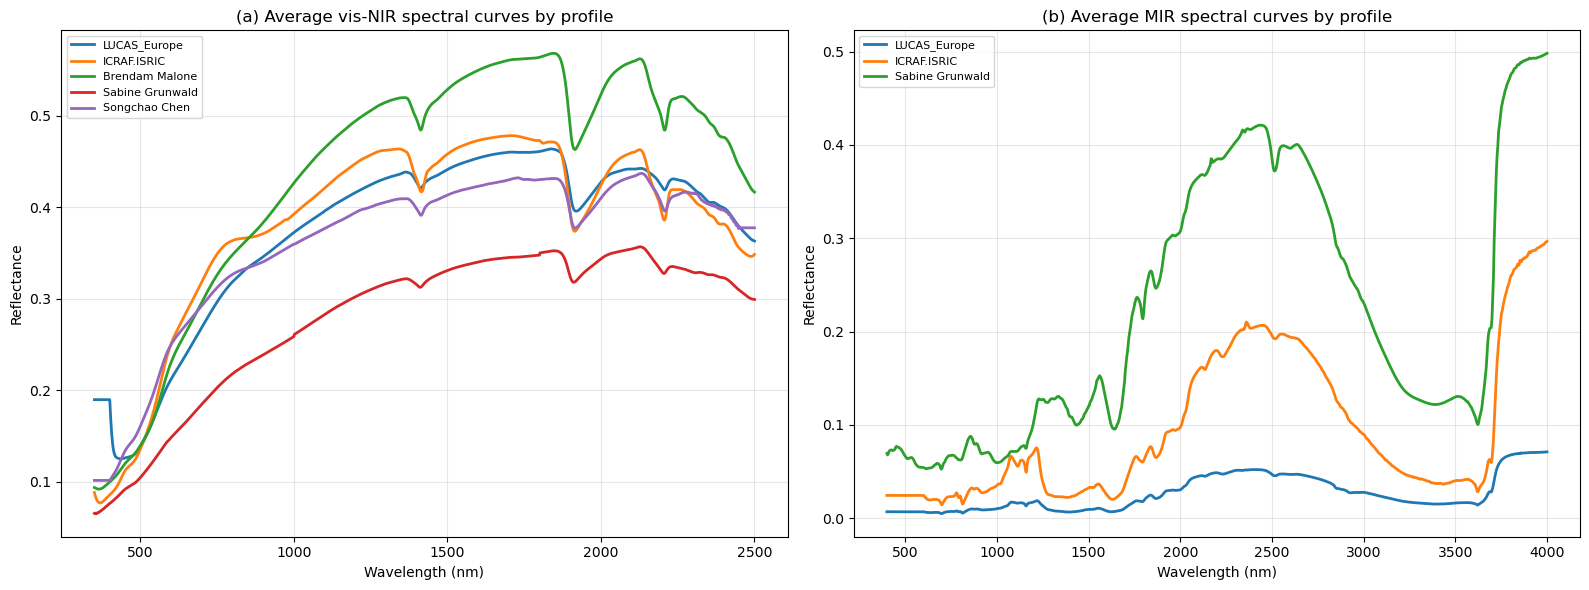

NIR file: raw_nir_data_saturin.csv (latin-1) | MIR file: raw_mir_data_saturin.csv (utf-8)
Profile variable used: Owner
Profiles plotted: ['LUCAS_Europe', 'ICRAF.ISRIC', 'Brendam Malone', 'Sabine Grunwald', 'Songchao Chen']
Saved: average_curves_visnir_mir_profiles.png


In [6]:
# Average spectral curves of vis-NIR (a) and MIR (b) for soil profiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _resolve_file(cands):
    p = next((Path(c) for c in cands if Path(c).exists()), None)
    if p is None:
        raise FileNotFoundError(f'File not found. Tried: {cands}')
    return p

def _read_csv_flexible(path):
    for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False), enc
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, f'Failed to decode {path.name}')

def _spectral_cols(df):
    wl = sorted(int(c) for c in df.columns if str(c).isdigit())
    return [str(w) for w in wl], np.array(wl)

nir_file = _resolve_file(['raw_nir_data_saturin.csv', 'raw_nir_data_Saturin.csv'])
mir_file = _resolve_file(['raw_mir_data_saturin.csv', 'raw_mir_data_Saturin.csv'])

nir_df, enc_nir = _read_csv_flexible(nir_file)
mir_df, enc_mir = _read_csv_flexible(mir_file)

nir_cols, nir_wl = _spectral_cols(nir_df)
mir_cols, mir_wl = _spectral_cols(mir_df)

nir_spec = nir_df[nir_cols].apply(pd.to_numeric, errors='coerce').fillna(method='ffill', axis=1).fillna(method='bfill', axis=1)
mir_spec = mir_df[mir_cols].apply(pd.to_numeric, errors='coerce').fillna(method='ffill', axis=1).fillna(method='bfill', axis=1)

# Profile variable: uses explicit profile if present, otherwise Owner (best available proxy).
profile_col = next((c for c in ['Profile', 'profile', 'Perfil', 'perfil'] if c in nir_df.columns), None)
if profile_col is None:
    profile_col = 'Owner' if 'Owner' in nir_df.columns else 'Country'

# Keep the most frequent profiles to keep figure readable.
top_profiles = nir_df[profile_col].astype(str).value_counts().head(5).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) vis-NIR average curves by profile
for prof in top_profiles:
    mask = nir_df[profile_col].astype(str) == prof
    curve = nir_spec.loc[mask].mean(axis=0).to_numpy()
    axes[0].plot(nir_wl, curve, lw=2, label=prof)
axes[0].set_title('(a) Average vis-NIR spectral curves by profile')
axes[0].set_xlabel('Wavelength (nm)')
axes[0].set_ylabel('Reflectance')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

# (b) MIR average curves by profile
for prof in top_profiles:
    mask = mir_df[profile_col].astype(str) == prof if profile_col in mir_df.columns else np.zeros(len(mir_df), dtype=bool)
    if np.any(mask):
        curve = mir_spec.loc[mask].mean(axis=0).to_numpy()
        axes[1].plot(mir_wl, curve, lw=2, label=prof)
axes[1].set_title('(b) Average MIR spectral curves by profile')
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_ylabel('Reflectance')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('average_curves_visnir_mir_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'NIR file: {nir_file.name} ({enc_nir}) | MIR file: {mir_file.name} ({enc_mir})')
print(f'Profile variable used: {profile_col}')
print('Profiles plotted:', top_profiles)
print('Saved: average_curves_visnir_mir_profiles.png')

## 6. Pre-processing, Spectra Fusion (SF1/SF2), and Classification Assessment

This section reproduces the methodology in Python:
- Resampling: vis-NIR to 10 nm (400-2450), MIR to 16 cm-1 (4008-600).
- Pre-processing: absorbance transform + Savitzky-Golay (order 2, window 11).
- Fusion:
  - SF1 (low-level): direct concatenation of vis-NIR and MIR bands.
  - SF2 (middle-level): OPA + PCA (top 20 PCs).
- Models: PLSDA and Random Forest with a 2:1 train/validation split and 10-fold CV for RF tuning.


Classification results (validation set):
            Data  Model  Accuracy     Kappa  Sensitivity_macro  \
0            MIR  PLSDA  0.974790  0.960285           0.962293   
1  SF2_OPA_PCA20  PLSDA  0.974790  0.960320           0.982265   
2   SF1_LowLevel  PLSDA  0.949580  0.922602           0.972575   
3        Vis-NIR  PLSDA  0.924370  0.881000           0.937281   
4  SF2_OPA_PCA20     RF  0.966387  0.945432           0.925278   
5            MIR     RF  0.941176  0.904833           0.860833   
6   SF1_LowLevel     RF  0.941176  0.905993           0.858611   
7        Vis-NIR     RF  0.663866  0.455689           0.586258   

   Precision_macro  
0         0.965359  
1         0.973440  
2         0.909250  
3         0.937879  
4         0.988732  
5         0.946984  
6         0.910509  
7         0.605123  


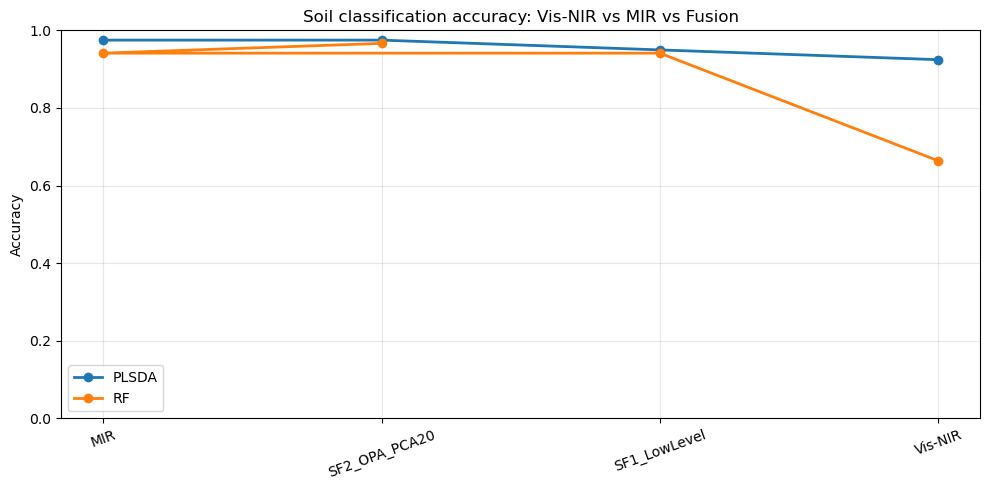


RF best max_features by dataset:
Vis-NIR {'max_features': 10}
MIR {'max_features': 2}
SF1_LowLevel {'max_features': 8}
SF2_OPA_PCA20 {'max_features': 3}

Saved: classification_visnir_mir_fusion_results.csv
Saved: classification_accuracy_visnir_mir_fusion.png
Classes used: ['ICRAF.ISRIC', 'KSSL.SSL', 'LUCAS_Europe', 'R. Poppiel / Dematte', 'Sabine Grunwald']
Sample size: 355 (train/valid ~= 2:1)


In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, precision_score, recall_score
import matplotlib.pyplot as plt

# ---------------------------
# 1) Load data and define label
# ---------------------------
def _resolve_file(cands):
    p = next((Path(c) for c in cands if Path(c).exists()), None)
    if p is None:
        raise FileNotFoundError(f'File not found. Tried: {cands}')
    return p

def _read_csv_flexible(path):
    for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False), enc
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, f'Failed to decode {path.name}')

def _spectral_cols(df):
    wl = sorted(int(c) for c in df.columns if str(c).isdigit())
    return [str(w) for w in wl], np.array(wl)

nir_file = _resolve_file(['raw_nir_data_saturin.csv', 'raw_nir_data_Saturin.csv'])
mir_file = _resolve_file(['raw_mir_data_saturin.csv', 'raw_mir_data_Saturin.csv'])

nir_df, enc_nir = _read_csv_flexible(nir_file)
mir_df, enc_mir = _read_csv_flexible(mir_file)

id_col = 'ID_Unico' if 'ID_Unico' in nir_df.columns and 'ID_Unico' in mir_df.columns else None
if id_col is None:
    raise KeyError('ID_Unico column is required in both NIR and MIR files for fusion workflow.')

# Soil class/category variable (fallback strategy).
label_col = next((c for c in ['Soil_Type', 'soil_type', 'Classe', 'classe', 'Profile', 'Owner', 'Country'] if c in nir_df.columns), None)
if label_col is None:
    raise KeyError('No class column found. Add one of: Soil_Type, classe, Profile, Owner, Country.')

nir_cols, nir_wl = _spectral_cols(nir_df)
mir_cols, mir_wl = _spectral_cols(mir_df)

nir_pack = nir_df[[id_col, label_col] + nir_cols].copy()
nir_pack = nir_pack.rename(columns={c: f'nir_{c}' for c in nir_cols})
mir_pack = mir_df[[id_col] + mir_cols].copy()
mir_pack = mir_pack.rename(columns={c: f'mir_{c}' for c in mir_cols})

# Keep only common samples across sensors
data = nir_pack.merge(mir_pack, on=id_col, how='inner')
data = data.dropna(subset=[label_col])

# Limit to top classes and sample size close to the paper setup (357 spectra).
top_classes = data[label_col].astype(str).value_counts().head(6).index.tolist()
data = data[data[label_col].astype(str).isin(top_classes)].copy()
target_n = min(357, len(data))
if target_n < 120:
    raise ValueError('Not enough samples after class filtering for robust modeling.')

# Stratified subsample
data = (
    data.groupby(label_col, group_keys=False)
        .apply(lambda g: g.sample(max(1, int(np.floor(target_n * len(g) / len(data)))), random_state=42))
        .reset_index(drop=True)
)
if len(data) > target_n:
    data = data.sample(target_n, random_state=42).reset_index(drop=True)

# ---------------------------
# 2) Resampling and pre-processing
# ---------------------------
# vis-NIR grid: 400-2450 nm every 10 nm -> 206 bands
nir_grid = np.arange(400, 2450 + 1, 10)
# MIR grid: 4008-600 cm^-1 every 16 cm^-1 -> 214 bands
mir_grid_desc = np.arange(4008, 600 - 1, -16)
mir_grid = np.sort(mir_grid_desc)  # ascending for interpolation

nir_wl_float = nir_wl.astype(float)
mir_wl_float = mir_wl.astype(float)

nir_raw = data[[f'nir_{c}' for c in nir_cols]].apply(pd.to_numeric, errors='coerce').to_numpy()
mir_raw = data[[f'mir_{c}' for c in mir_cols]].apply(pd.to_numeric, errors='coerce').to_numpy()

# NaN fill by column median
nir_raw = np.where(np.isnan(nir_raw), np.nanmedian(nir_raw, axis=0, keepdims=True), nir_raw)
mir_raw = np.where(np.isnan(mir_raw), np.nanmedian(mir_raw, axis=0, keepdims=True), mir_raw)

def _interp_rows(X, x_old, x_new):
    out = np.empty((X.shape[0], len(x_new)), dtype=float)
    for i in range(X.shape[0]):
        out[i] = np.interp(x_new, x_old, X[i])
    return out

nir_rs = _interp_rows(nir_raw, nir_wl_float, nir_grid)
mir_rs = _interp_rows(mir_raw, mir_wl_float, mir_grid)

# Absorbance conversion: A = log10(1/R)
eps = 1e-8
nir_abs = np.log10(1.0 / np.clip(nir_rs, eps, None))
mir_abs = np.log10(1.0 / np.clip(mir_rs, eps, None))

# Savitzky-Golay smoothing: order=2, window=11
nir_pp = savgol_filter(nir_abs, window_length=11, polyorder=2, axis=1)
mir_pp = savgol_filter(mir_abs, window_length=11, polyorder=2, axis=1)

# ---------------------------
# 3) Fusion strategies
# ---------------------------
# SF1: low-level (206 + 214 = 420 bands)
X_sf1 = np.hstack([nir_pp, mir_pp])

# SF2: middle-level (OPA + PCA top 20)
def _opa_features(Xa, Xb):
    n, a = Xa.shape
    _, b = Xb.shape
    out = np.empty((n, a * b), dtype=float)
    for i in range(n):
        out[i] = np.outer(Xa[i], Xb[i]).ravel()
    return out

X_opa = _opa_features(nir_pp, mir_pp)
pca = PCA(n_components=20, random_state=42)
X_sf2 = pca.fit_transform(X_opa)

# Also keep standalone inputs for comparison
X_nir = nir_pp
X_mir = mir_pp

# ---------------------------
# 4) Train/validation split (2:1)
# ---------------------------
y_str = data[label_col].astype(str).to_numpy()
le = LabelEncoder()
y = le.fit_transform(y_str)

def _split_xy(X):
    return train_test_split(
        X, y, test_size=1/3, random_state=42, stratify=y
    )

# ---------------------------
# 5) Models: PLSDA and RF
# ---------------------------
def _fit_plsda_predict(X_train, y_train, X_valid, n_comp=10):
    y_train_oh = pd.get_dummies(y_train).to_numpy()
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_valid_s = scaler.transform(X_valid)

    n_comp = int(min(n_comp, X_train_s.shape[1], len(np.unique(y_train)) + 5, X_train_s.shape[0] - 1))
    pls = PLSRegression(n_components=max(2, n_comp))
    pls.fit(X_train_s, y_train_oh)
    y_pred_score = pls.predict(X_valid_s)
    y_pred = np.argmax(y_pred_score, axis=1)
    return y_pred

def _fit_rf_predict(X_train, y_train, X_valid):
    rf = RandomForestClassifier(random_state=42, n_estimators=500, n_jobs=-1)
    grid = GridSearchCV(
        rf,
        param_grid={'max_features': list(range(1, 11))},
        cv=10,
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    y_pred = grid.best_estimator_.predict(X_valid)
    return y_pred, grid.best_params_

def _metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'kappa': cohen_kappa_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'sensitivity_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }

experiments = {
    'Vis-NIR': X_nir,
    'MIR': X_mir,
    'SF1_LowLevel': X_sf1,
    'SF2_OPA_PCA20': X_sf2,
}

rows = []
rf_params = {}

for name, X in experiments.items():
    X_train, X_valid, y_train, y_valid = _split_xy(X)

    y_pred_pls = _fit_plsda_predict(X_train, y_train, X_valid, n_comp=10)
    m_pls = _metrics(y_valid, y_pred_pls)
    rows.append([name, 'PLSDA', m_pls['accuracy'], m_pls['kappa'], m_pls['sensitivity_macro'], m_pls['precision_macro']])

    y_pred_rf, best_rf = _fit_rf_predict(X_train, y_train, X_valid)
    m_rf = _metrics(y_valid, y_pred_rf)
    rows.append([name, 'RF', m_rf['accuracy'], m_rf['kappa'], m_rf['sensitivity_macro'], m_rf['precision_macro']])
    rf_params[name] = best_rf

results = pd.DataFrame(rows, columns=['Data', 'Model', 'Accuracy', 'Kappa', 'Sensitivity_macro', 'Precision_macro'])
results = results.sort_values(['Model', 'Accuracy'], ascending=[True, False]).reset_index(drop=True)
print('\nClassification results (validation set):')
print(results)

# Save results
results.to_csv('classification_visnir_mir_fusion_results.csv', index=False)

# Plot accuracy by model/data
fig, ax = plt.subplots(figsize=(10, 5))
for model in ['PLSDA', 'RF']:
    sub = results[results['Model'] == model]
    ax.plot(sub['Data'], sub['Accuracy'], marker='o', linewidth=2, label=model)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Soil classification accuracy: Vis-NIR vs MIR vs Fusion')
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('classification_accuracy_visnir_mir_fusion.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nRF best max_features by dataset:')
for k, v in rf_params.items():
    print(k, v)

print('\nSaved: classification_visnir_mir_fusion_results.csv')
print('Saved: classification_accuracy_visnir_mir_fusion.png')
print('Classes used:', list(le.classes_))
print('Sample size:', len(data), '(train/valid ~= 2:1)')

## Poppiel et al. (2022) pipeline in this dataset

This section reproduces the core method logic from *Poppiel et al., 2022* (Geoderma 425):

1. Use vis-NIR spectra (350-2500 nm) and resample to 10 nm.
2. Build an **unsupervised random forest** (real spectra vs synthetic-permuted spectra) to obtain sample proximities.
3. Project proximities with classical MDS and cluster samples.
4. Detect outliers per cluster with an adjusted-boxplot strategy based on medcouple skewness.
5. Select train/test samples systematically from ordered important-band reflectance.
6. Train spectral regression models for routine attributes and compare split sizes.

Note: the original paper uses Cubist (R). Here we use a robust Python equivalent (`RandomForestRegressor`) so the pipeline runs directly in this environment.

C:\Users\PC\AppData\Local\Temp\ipykernel_6988\1586458990.py:16: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, encoding=enc)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by 

Owner/Lab subset: R. Poppiel / Dematte
Samples total (subset): 1002
Outliers flagged: 33 (3.29%)
Samples kept: 969

Top results by target (lower RMSE):
     target                 owner  split  n_train  n_test        rmse  \
0  Clay_gkg  R. Poppiel / Dematte  67_33      529     275   88.772457   
1  Sand_gkg  R. Poppiel / Dematte  67_33      529     275  130.307000   

         r2  
0  0.585173  
1  0.600451  


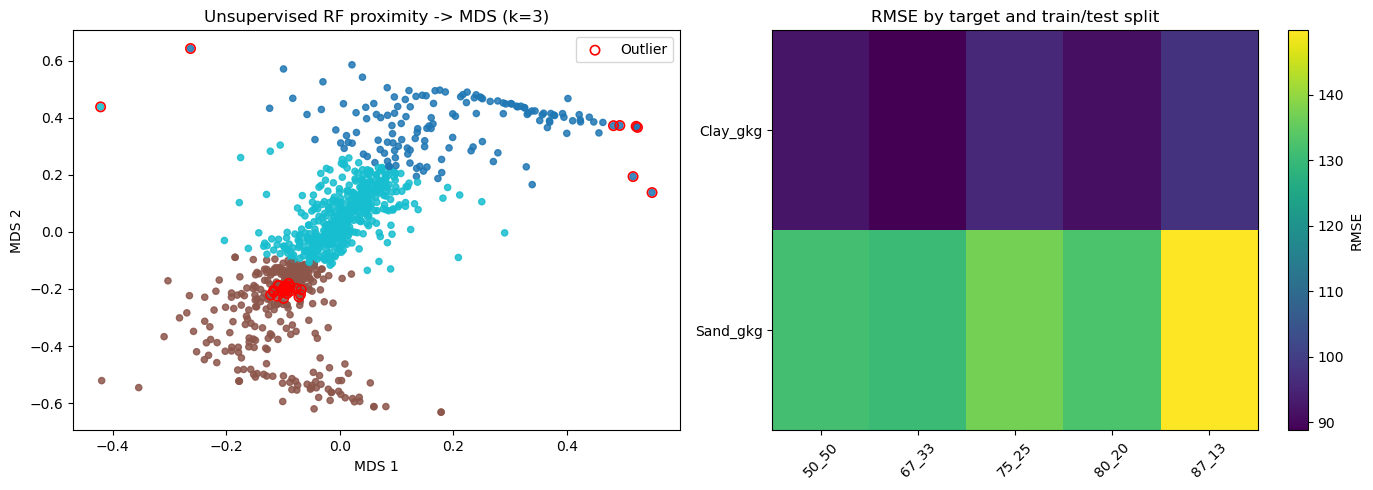


Saved:
- poppiel_2022_pipeline_results.csv
- poppiel_2022_wavelength_importance.csv
- poppiel_2022_pipeline_summary.png

Top important wavelengths (10 nm grid):
[ 710.  850.  940. 1030. 1070. 1110. 1130. 1160. 1220. 1240. 1250. 1260.
 1270. 1310. 1330. 1340. 1360. 1410. 1460. 1560. 1580. 1620. 1630. 1650.
 1690.]


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score, mean_squared_error


# ---------- Helpers ----------
def robust_read_csv(path: Path) -> pd.DataFrame:
    for enc in ["utf-8", "utf-8-sig", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("csv", b"", 0, 1, f"Could not decode {path.name}")


def get_spectral_matrix(df: pd.DataFrame):
    spec_cols = [c for c in df.columns if str(c).strip().isdigit()]
    wl = np.array([float(c) for c in spec_cols], dtype=float)
    X = df[spec_cols].apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median(numeric_only=True)).to_numpy(dtype=float)
    return X, wl, spec_cols


def resample_10nm(X: np.ndarray, wl: np.ndarray):
    grid = np.arange(wl.min(), wl.max() + 1e-9, 10.0)
    Xr = np.array([np.interp(grid, wl, row) for row in X], dtype=float)
    return Xr, grid


def build_unsupervised_rf(X: np.ndarray, n_estimators=250, random_state=42):
    rng = np.random.default_rng(random_state)
    X_synth = np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])])
    X_aug = np.vstack([X, X_synth])
    y_aug = np.hstack([np.ones(X.shape[0], dtype=int), np.zeros(X.shape[0], dtype=int)])

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
    clf.fit(X_aug, y_aug)
    return clf


def proximity_from_rf(clf: RandomForestClassifier, X: np.ndarray):
    # Memory-safe proximity computation from shared terminal nodes.
    leaves = clf.apply(X)
    n, t = leaves.shape
    prox = np.zeros((n, n), dtype=np.float32)

    for k in range(t):
        lv = leaves[:, k]
        for leaf_id in np.unique(lv):
            idx = np.where(lv == leaf_id)[0]
            prox[np.ix_(idx, idx)] += 1.0

    prox /= float(t)
    return prox


def medcouple_naive(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 5:
        return 0.0

    x = np.sort(x)
    m = np.median(x)
    xl = x[x <= m]
    xu = x[x >= m]

    A = (xu[:, None] - m)
    B = (m - xl[None, :])
    den = A + B
    num = A - B

    with np.errstate(divide="ignore", invalid="ignore"):
        h = np.where(den == 0, 0, num / den)

    return float(np.median(h[np.isfinite(h)]))


def adjusted_boxplot_bounds(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 5:
        q1, q3 = np.quantile(x, [0.25, 0.75]) if x.size else (0, 0)
        iqr = q3 - q1
        return q1 - 1.5 * iqr, q3 + 1.5 * iqr

    q1, q3 = np.quantile(x, [0.25, 0.75])
    iqr = q3 - q1
    mc = medcouple_naive(x)

    if mc >= 0:
        lower = q1 - 1.5 * np.exp(-4 * mc) * iqr
        upper = q3 + 1.5 * np.exp(3 * mc) * iqr
    else:
        lower = q1 - 1.5 * np.exp(-3 * mc) * iqr
        upper = q3 + 1.5 * np.exp(4 * mc) * iqr

    return lower, upper


def systematic_split_indices(n: int, train_ratio: float):
    k = int(round(1.0 / (1.0 - train_ratio)))
    k = max(k, 2)
    n_train_per_block = min(k - 1, int(round(train_ratio * k)))
    n_train_per_block = max(1, n_train_per_block)

    train_mask = np.zeros(n, dtype=bool)
    for i in range(n):
        if (i % k) < n_train_per_block:
            train_mask[i] = True

    return np.where(train_mask)[0], np.where(~train_mask)[0]


# ---------- Data loading ----------
root = Path.cwd()
nir_file = root / "raw_nir_data_Saturin.csv"
df_full = robust_read_csv(nir_file)

# Follow article's by-laboratory routine. Prefer your known lab group when available.
if "Owner" in df_full.columns:
    owner_counts = df_full["Owner"].astype(str).value_counts()
    preferred = "R. Poppiel / Dematte"
    if preferred in owner_counts.index:
        selected_owner = preferred
    else:
        selected_owner = owner_counts.index[0]

    df = df_full[df_full["Owner"].astype(str) == selected_owner].copy()
else:
    selected_owner = "ALL"
    df = df_full.copy()

# Safety cap for proximity matrix (keeps runtime/memory bounded)
MAX_SAMPLES = 2500
if len(df) > MAX_SAMPLES:
    df = df.sample(MAX_SAMPLES, random_state=42).copy()

X_raw, wl_raw, spec_cols = get_spectral_matrix(df)
X_10, wl_10 = resample_10nm(X_raw, wl_raw)

# Candidate routine attributes from article context
target_map = {
    "Clay_gkg": "Clay_gkg",
    "Sand_gkg": "Sand_gkg",
    "OM_gkg": "OM_gkg",
    "CEC_Ph7_mmolkg": "CEC_Ph7_mmolkg",
}

# Compute V% if possible: ((Ca+Mg+K)*100)/CEC
if all(c in df.columns for c in ["Ca_mmolkg", "Mg_mmolkg", "K_mmolkg", "CEC_Ph7_mmolkg"]):
    cec = pd.to_numeric(df["CEC_Ph7_mmolkg"], errors="coerce")
    bases = (
        pd.to_numeric(df["Ca_mmolkg"], errors="coerce")
        + pd.to_numeric(df["Mg_mmolkg"], errors="coerce")
        + pd.to_numeric(df["K_mmolkg"], errors="coerce")
    )
    v_pct = (bases * 100.0) / cec.replace(0, np.nan)
    df["V_pct"] = v_pct
    target_map["V_pct"] = "V_pct"

available_targets = [c for c in target_map.values() if c in df.columns]

# ---------- 2.3: Unsupervised RF, proximity, MDS, clustering ----------
urf = build_unsupervised_rf(X_10, n_estimators=250, random_state=42)
prox = proximity_from_rf(urf, X_10)
dist = 1.0 - prox

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
xy = mds.fit_transform(dist)

sil = {}
for k in range(2, 9):
    labels_k = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(xy)
    sil[k] = silhouette_score(xy, labels_k)

best_k = max(sil, key=sil.get)
cluster = KMeans(n_clusters=best_k, n_init=50, random_state=42).fit_predict(xy)

# ---------- 2.3: Outliers by adjusted boxplot inside each cluster ----------
outlier = np.zeros(len(df), dtype=bool)
for g in np.unique(cluster):
    idx = np.where(cluster == g)[0]
    if idx.size < 10:
        continue

    d = np.sqrt((xy[idx, 0] - np.median(xy[idx, 0])) ** 2 + (xy[idx, 1] - np.median(xy[idx, 1])) ** 2)
    lo, hi = adjusted_boxplot_bounds(d)
    outlier[idx] = (d < lo) | (d > hi)

keep = ~outlier
print(f"Owner/Lab subset: {selected_owner}")
print(f"Samples total (subset): {len(df)}")
print(f"Outliers flagged: {outlier.sum()} ({100*outlier.mean():.2f}%)")
print(f"Samples kept: {keep.sum()}")

# ---------- 2.4: Selection by important wavelengths ----------
imp = urf.feature_importances_
thr = 0.70 * imp.max()
important_idx = np.where(imp >= thr)[0]
if important_idx.size == 0:
    important_idx = np.argsort(imp)[-20:]

important_wl = wl_10[important_idx]
mean_imp_reflect = X_10[:, important_idx].mean(axis=1)

idx_kept = np.where(keep)[0]
order_local = np.argsort(mean_imp_reflect[idx_kept])
ordered_idx = idx_kept[order_local]

split_map = {
    "50_50": 0.50,
    "67_33": 0.67,
    "75_25": 0.75,
    "80_20": 0.80,
    "87_13": 0.87,
}

# ---------- 2.4.2: Attribute modeling ----------
rows = []
for split_name, ratio in split_map.items():
    tr_pos, te_pos = systematic_split_indices(len(ordered_idx), ratio)
    idx_tr = ordered_idx[tr_pos]
    idx_te = ordered_idx[te_pos]

    Xtr = X_raw[idx_tr, :]
    Xte = X_raw[idx_te, :]

    for target in available_targets:
        y = pd.to_numeric(df[target], errors="coerce").to_numpy(dtype=float)
        mtr = np.isfinite(y[idx_tr])
        mte = np.isfinite(y[idx_te])

        if mtr.sum() < 40 or mte.sum() < 20:
            continue

        model = RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            min_samples_leaf=2,
        )
        model.fit(Xtr[mtr], y[idx_tr][mtr])
        pred = model.predict(Xte[mte])

        rmse = mean_squared_error(y[idx_te][mte], pred) ** 0.5
        r2 = r2_score(y[idx_te][mte], pred)
        rows.append(
            {
                "owner": selected_owner,
                "split": split_name,
                "target": target,
                "n_train": int(mtr.sum()),
                "n_test": int(mte.sum()),
                "rmse": float(rmse),
                "r2": float(r2),
            }
        )

results_poppiel2022 = pd.DataFrame(rows).sort_values(["target", "rmse"]) if rows else pd.DataFrame()

print("\nTop results by target (lower RMSE):")
if not results_poppiel2022.empty:
    print(results_poppiel2022.groupby("target", as_index=False).first())
else:
    print("No valid models were generated for this subset.")

# ---------- Save artifacts ----------
if not results_poppiel2022.empty:
    results_poppiel2022.to_csv(root / "poppiel_2022_pipeline_results.csv", index=False)

pd.DataFrame({
    "wavelength_nm_10grid": wl_10,
    "importance": imp,
    "is_top70pct": imp >= thr,
}).to_csv(root / "poppiel_2022_wavelength_importance.csv", index=False)

# ---------- Plots ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(xy[:, 0], xy[:, 1], c=cluster, s=20, cmap="tab10", alpha=0.85)
axes[0].scatter(xy[outlier, 0], xy[outlier, 1], s=45, facecolors="none", edgecolors="red", linewidths=1.2, label="Outlier")
axes[0].set_title(f"Unsupervised RF proximity -> MDS (k={best_k})")
axes[0].set_xlabel("MDS 1")
axes[0].set_ylabel("MDS 2")
axes[0].legend(loc="best")

if not results_poppiel2022.empty:
    pivot = results_poppiel2022.pivot_table(index="target", columns="split", values="rmse", aggfunc="mean")
    pivot = pivot.reindex(columns=["50_50", "67_33", "75_25", "80_20", "87_13"])
    im = axes[1].imshow(pivot.fillna(np.nan).values, aspect="auto", cmap="viridis")
    axes[1].set_yticks(range(len(pivot.index)))
    axes[1].set_yticklabels(pivot.index)
    axes[1].set_xticks(range(len(pivot.columns)))
    axes[1].set_xticklabels(pivot.columns, rotation=45)
    axes[1].set_title("RMSE by target and train/test split")
    plt.colorbar(im, ax=axes[1], label="RMSE")
else:
    axes[1].text(0.5, 0.5, "No valid models", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(root / "poppiel_2022_pipeline_summary.png", dpi=160)
plt.show()

print("\nSaved:")
if not results_poppiel2022.empty:
    print("- poppiel_2022_pipeline_results.csv")
print("- poppiel_2022_wavelength_importance.csv")
print("- poppiel_2022_pipeline_summary.png")
print("\nTop important wavelengths (10 nm grid):")
print(np.round(important_wl[:25], 1))